#  Gravitational Wave Data Analysis tutorial #2

This notebook gives an introductions to Bayesian inference and parameter inference for gravitational wave signals from compact binary coalescences (CBCs), with an application to recover the (simplified) parameters of GW150914 in real data.

We refer to the lectures and tutorials available at the GWOSC: [Gravitational-Wave Open Science Center (GWOSC)](https://www.gw-openscience.org).

Another useful workshop dealing with the simulation and analysis of LISA data is available here: [LISA Data Generation and Analysis Workshop](https://indico.in2p3.fr/event/33255/overview)
    
[Click this link to view this tutorial in Google Colaboratory](https://colab.research.google.com/github/SylvainMarsat/gwda_tutorial/blob/main/tutorial_2.ipynb)

Author date

When running in Google Colab, uncomment and run the cell to install latex for matplotlib:

## Install

When running in Google Colab, uncomment and run the cell to install required packages:

In [ ]:
#! pip install numpy scipy h5py matplotlib ipython jupyterlab tqdm lalsuite gwpy eryn corner bilby

When running in Google Colab, uncomment and run the cell to download the required data:

## Imports

In [33]:
import os, sys
import h5py, json
import copy
import numpy as np
import scipy
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

from tqdm import tqdm as tqdm

import astropy.units as u

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio") # to silence a warning
warnings.filterwarnings("ignore", category=DeprecationWarning) 
import lal
import lalsimulation
import lalsimulation.gwsignal.core.waveform as wfm
from lalsimulation.gwsignal import gwsignal_get_waveform_generator

import gwpy

# import ptemcee
import eryn
import corner
import bilby

In [2]:
%matplotlib inline

## Definitions

In [97]:
colors = ["#4C72B0", "#C44E52", "#CCB974", "#55A868", "#8172B2", "#64B5CD", '#FFA500', '#A0522D']

rc_params = {'backend': 'ps',
            'axes.unicode_minus':False,
            'axes.grid':True,
            'lines.linewidth':1.,
            'grid.linestyle':':',
            'grid.linewidth':1.,
            'hist.bins':50,
            'axes.labelsize':16,
            'axes.titlesize':16,
            'xtick.labelsize':16,
            'ytick.labelsize':16,
            'legend.fontsize':16,
            'figure.dpi':100}
plt.rcParams.update(rc_params)

In [98]:
# Definitions for the windowing function -- function for vectorial argument
# In order to avoid overflows in the exponentials, we set the boundaries (di, df) so that anything below 10^-20 is considered zero
def window_planck(x, xi, xf, deltaxi, deltaxf):
    di = deltaxi/(20*np.log(10))
    df = deltaxf/(20*np.log(10))
    w = np.zeros(len(x), dtype=float)
    #
    mask = (x <= xi + di) | (x >= xf - df)
    w[mask] = 0.
    #
    mask = (xi + di < x) & (x < xi + deltaxi - di)
    xm = x[mask]
    w[mask] = 1./(1 + np.exp(deltaxi/(xm - xi) + deltaxi/(xm - (xi + deltaxi))))
    #
    mask = (xi + deltaxi - di <= x) & (x <= xf - deltaxf + df)
    w[mask] = 1.
    #
    mask = (xf - deltaxf + df < x) & (x < xf - df)
    xm = x[mask]
    w[mask] = 1./(1 + np.exp(-(deltaxf/(xm - (xf - deltaxf))) - deltaxf/(xm - xf)))
    #
    return w

In [99]:
def fft_positivef(times, data):
    n = len(times)
    deltat = times[1] - times[0]
    deltaf = 1./(n*deltat)
    # Fast Fourier Transform
    freqs = deltaf*np.arange(n)
    # BEWARE: due to the different convention for the sign of Fourier frequencies, we have to reverse the FFT output
    # Beware also that the FFT treats effectively the initial time as 0
    # BEWARE: in the reversion of the numpy-convention FFT output, we have to set aside the 0-frequency term
    data_fd = deltat * np.fft.fft(data)
    # Discarding information on negative frequencies - if real timeseries in input, no information loss as the deleted values are the conjugate
    data_fd = data_fd[:n//2+1]
    freqs = freqs[:n//2+1]
    # Coming back to the initial times
    tshift = times[0]
    fac_timeshift = np.exp(1j*2*np.pi*freqs*tshift)
    data_fd = data_fd * fac_timeshift
    return freqs, data_fd

In [100]:
def ifft_positivef(freqs, data, tstart=0., real=False):
    # Assumes n = N/2+1, with N length of data
    n = len(freqs)
    deltaf = freqs[1] - freqs[0]
    # Zero-pad to next power of 2, then 0-pad by factor 2 for the negative frequencies
    N = 2*(n - 1)
    # N_pad = 2**(int(np.ceil(np.log(N) / np.log(2))) + 1)
    freqs_pad = deltaf * np.arange(N)
    data_pad = np.zeros(N, dtype=data.dtype)
    data_pad[:n] = data
    # If data is FFT of real data, complete implicit f<0 values in the second half of the vector
    if real:
        data_pad[n:] = np.conj(data[1:n-1][::-1])
    # Factor to restore times
    fac_timeshift = np.exp(-1j*2*np.pi*freqs_pad*tstart)
    # Inverse FFT
    deltat = 1./(N*deltaf)
    data_td = 1./deltat * np.fft.ifft(fac_timeshift * data_pad)
    if real:
        data_td = np.real(data_td)
    # Rebuild times
    times = tstart + deltat * np.arange(N)
    return times, data_td

# Part I: basics of Bayesian inference with Gaussian distributions 

## Definitions

In [3]:
def normal_pdf(x, mean, invcov, detcov=None, normalized=True):
    mean = np.atleast_1d(mean)
    invcov = np.atleast_2d(invcov)
    x = np.atleast_2d(x)
    n = mean.shape[0]
    u = (x.T - mean).T
    pdf = np.exp(-1./2 * np.sum(u * np.dot(invcov, u), axis=0))
    if normalized:
        if detcov is None:
            detcov = 1./np.linalg.det(invcov) 
        pdf /= (2*np.pi)**(n/2.) * np.sqrt(detcov)
    return pdf

def normal_logpdf(x, mean, invcov, detcov=None, normalized=True):
    mean = np.atleast_1d(mean)
    invcov = np.atleast_2d(invcov)
    x = np.atleast_2d(x)
    n = mean.shape[0]
    u = (x.T - mean).T
    logpdf = -1./2 * np.sum(u * np.dot(invcov, u), axis=0)
    if normalized:
        if detcov is None:
            detcov = 1./np.linalg.det(invcov) 
        logpdf -= n/2. * np.log(2*np.pi) + 1./2 * np.log(detcov)
    return logpdf

In [20]:
class normal_proposal:
    '''
    Simple class for a proposal, for drawing a new point and also evaluating the prob. density of the jump
    '''
    def __init__(self, cov):
        self.n_dim = cov.shape[0]
        self.mean = np.zeros(n_dim, dtype=float)
        self.cov = cov
        self.invcov = np.linalg.inv(cov)
        self.detcov = np.linalg.det(cov)
    def draw(self, x):
        # NOTE: this is inefficient, we should diagonalize cov once and for all, here it is done at each step
        return x + np.random.multivariate_normal(self.mean, self.cov)
    def density(self, x, y):
        u = y - x
        return 1./(2*np.pi)**(self.n_dim/2.)/np.sqrt(self.detcov) * np.exp(-1./2 * np.linalg.multi_dot([u, self.invcov, u]))

class MHMCMC:
    '''
    Simple class for a single-walker MH-MCMC sampler
    '''
    def __init__(self, n_dim, x_ini=None, loglikelihood=None, logprior=None, proposal=None, seed=None):
        self.n_dim = n_dim
        self.loglikelihood = loglikelihood
        self.logprior = logprior
        self.proposal = proposal
        self.x = None
        self.lnL = None
        self.lnprior = None
        self.lnpost = None
        self.seed = seed
        self.x = None
        if x_ini is None:
            self.x_ini = np.zeros(n_dim, dtype=float)
        else:
            self.x_ini = x_ini
    
    def step(self, x, lnL, lnprior, lnpost, i):
        # y current point, z new point
        y = x[i-1]
        lnpost_y = lnpost[i-1]
        z = self.proposal.draw(y)
        q_yz = self.proposal.density(y, z)
        q_zy = self.proposal.density(z, y)
        lnlike_z = self.loglikelihood(z)
        lnprior_z = self.logprior(z)
        lnpost_z = lnlike_z + lnprior_z
        alpha_yz = np.fmin(1., np.exp(lnpost_z - lnpost_y) * q_zy / q_yz)
        u = np.random.uniform()
        accept = (u < alpha_yz)
        if accept:
            x[i] = z
            lnL[i] = lnlike_z
            lnprior[i] = lnprior_z
            lnpost[i] = lnpost_z
        else:
            x[i] = y
            lnL[i] = lnL[i-1]
            lnprior[i] = lnprior[i-1]
            lnpost[i] = lnpost[i-1]
        return accept
        
    def run(self, n_iter, monitor=True):
        self.x = np.zeros((n_iter, n_dim), dtype=float)
        self.lnL = np.zeros(n_iter, dtype=float)
        self.lnprior = np.zeros(n_iter, dtype=float)
        self.lnpost = np.zeros(n_iter, dtype=float)
        self.x[0] = self.x_ini.copy()
        self.lnL[0] = self.loglikelihood(self.x[0])
        self.lnprior[0] = self.logprior(self.x[0])
        self.lnpost[0] = self.lnL[0] + self.lnprior[0]
        if self.seed is not None:
            np.random.seed(self.seed)
        for i in tqdm(range(1, n_iter), disable=(not monitor)):
            accept = self.step(self.x, self.lnL, self.lnprior, self.lnpost, i)

## MH-MCMC simple example: 1D Gaussian

In [11]:
n_dim = 1

mean_val = 0.

prior_range = [[-10., 10.]]

mean = mean_val + np.zeros(n_dim, dtype=float)
x_ini = np.zeros(n_dim) + mean_val

# Build artificially some positive-definite covariance
A = np.ones((n_dim, n_dim), dtype=float)
cov = np.dot(A.T, A)
invcov = np.linalg.inv(cov)
detcov = np.linalg.det(cov)

def loglikelihood(x):
    return normal_logpdf(x, mean, invcov, normalized=False)
def logprior(x):
    for i in range(n_dim):
        if (x[i] < prior_range[i][0] or prior_range[i][1] < x[i]):
            return -np.infty
    return 1.

# Arbitrary covariance for the proposal
B = 0.5 * np.ones((n_dim, n_dim), dtype=float)
cov_prop = np.dot(B.T, B)
proposal = normal_proposal(cov_prop)

sampler = MHMCMC(1, x_ini=x_ini, loglikelihood=loglikelihood, logprior=logprior, proposal=proposal, seed=1)

In [34]:
sampler.run(10000)

100%|███████████████████████████████████████████████████████████████████████████████| 9999/9999 [00:01<00:00, 5623.62it/s]


/tmp/ipykernel_32507/2574913923.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  target_p[i] = normal_pdf(x_arr[i], mean, invcov, normalized=True)


Text(0.5, 0, '$x$')

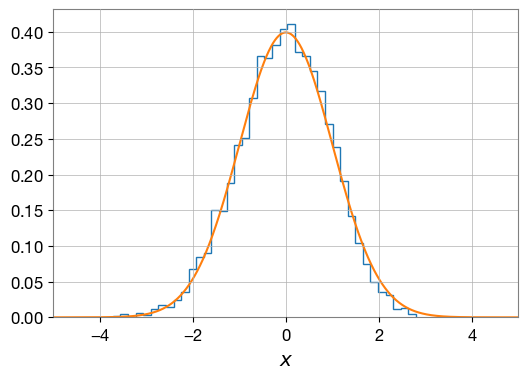

In [15]:
x_arr = np.linspace(-5., 5., 1000)
target_p = np.zeros_like(x_arr)
for i in range(x_arr.shape[0]):
    target_p[i] = normal_pdf(x_arr[i], mean, invcov, normalized=True)

fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.hist(sampler.x.flatten(), histtype='step', density=True, bins=40);#, label=r'$n_{\rm dim}=' + str(n_dim) + '$', color=plotpalette[i])
ax.plot(x_arr, target_p)
ax.set_xlim(-5., 5.)
ax.set_xlabel(r'$x$')

Text(0, 0.5, '$x$')

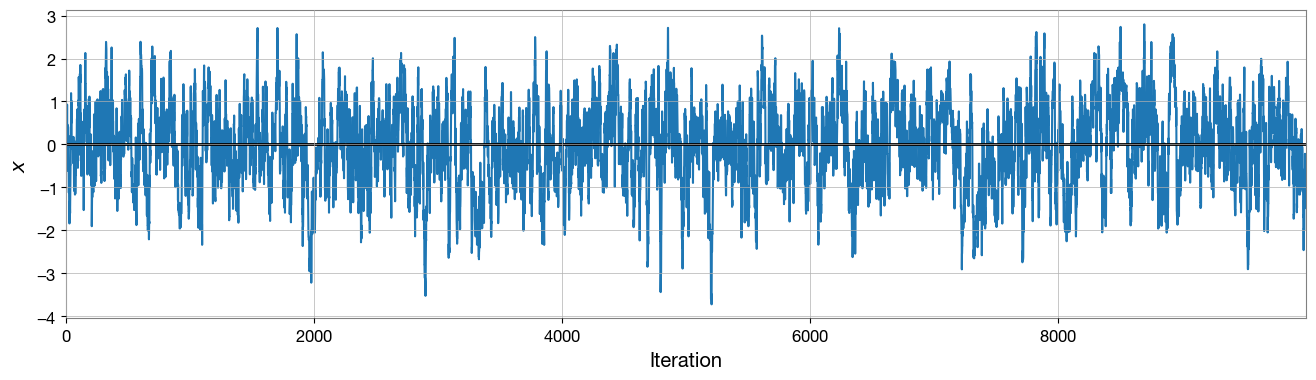

In [17]:
fig, ax = plt.subplots(1,1, figsize=[16,4])
ax.plot(sampler.x.flatten())
ax.set_xlim(0, sampler.x.shape[0]-1)
ax.axhline(mean_val, c='k', lw=2.)
ax.set_xlabel(r'Iteration')
ax.set_ylabel(r'$x$')

## Simulating noisy observations

In [18]:
n_dim = 1

mean_val = 0.

prior_range = [[-10., 10.]]

mean = mean_val + np.zeros(n_dim, dtype=float)
x_ini = np.zeros(n_dim) + mean_val

# Build artificially some positive-definite covariance
A = np.ones((n_dim, n_dim), dtype=float)
cov = np.dot(A.T, A)
invcov = np.linalg.inv(cov)
detcov = np.linalg.det(cov)

def draw_noise():
    return np.random.normal(mean, cov)[0,0]
def logprior(x):
    for i in range(n_dim):
        if (x[i] < prior_range[i][0] or prior_range[i][1] < x[i]):
            return -np.infty
    return 1.

# Arbitrary covariance for the proposal
B = 0.5 * np.ones((n_dim, n_dim), dtype=float)
cov_prop = np.dot(B.T, B)
proposal = normal_proposal(cov_prop)

In [19]:
n_noise_real = 100

np.random.seed(1)

# NOTE: we do not draw the signal according to the prior - in principle we should
signal = np.zeros(n_noise_real, dtype=float)
noise = np.zeros(n_noise_real, dtype=float)
for i in range(n_noise_real):
#     signal[i] = np.random.uniform(low=prior_range[0][0], high=prior_range[0][1])
    signal[i] = mean_val
    noise[i] = draw_noise()

In [21]:
n_iter = 4000
burn_in = 2000

samples_noise_real = np.zeros((n_noise_real,n_iter-burn_in), dtype=float)
for i in tqdm(range(n_noise_real)):
    d = signal[i] + noise[i]
    def loglikelihood(x):
        return normal_logpdf(x, np.array([d]), invcov, normalized=False)
    sampler = MHMCMC(1, x_ini=x_ini, loglikelihood=loglikelihood, logprior=logprior, proposal=proposal, seed=1)
    sampler.run(n_iter, monitor=False)
    samples_noise_real[i] = sampler.x.flatten()[burn_in:]

  0%|                                                                                             | 0/100 [00:00<?, ?it/s]/tmp/ipykernel_32507/1087509947.py:69: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  self.lnL[0] = self.loglikelihood(self.x[0])
/tmp/ipykernel_32507/1087509947.py:53: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lnL[i] = lnlike_z
/tmp/ipykernel_32507/1087509947.py:55: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lnpost[i] = lnpost_z
100%|████

Text(0.5, 0, '$x$')

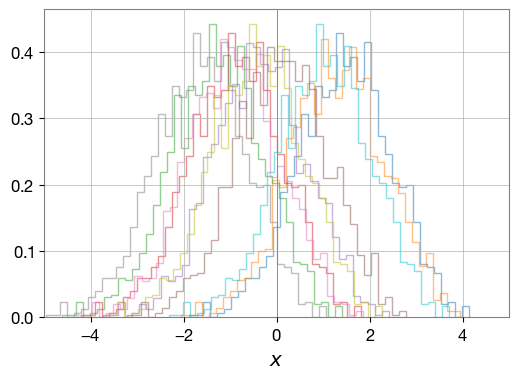

In [23]:
fig, ax = plt.subplots(1,1, figsize=[6,4])
for i in range(n_noise_real)[::10]:
    ax.hist(samples_noise_real[i], histtype='step', density=True, alpha=0.5, bins=40);#, label=r'$n_{\rm dim}=' + str(n_dim) + '$', color=plotpalette[i])
ax.axvline(0., c='k', lw=0.5)
ax.set_xlim(-5., 5.)
ax.set_xlabel(r'$x$')

In [24]:
def pvalue_from_post(s, samples):
    m = np.median(samples)
    if m <= s:
        return 2 * np.sum(s < samples) / len(samples)
    else:
        return 2 * np.sum(samples < s) / len(samples)

# Theoretical interval, at the level prob
# The cumulative fraction, for each p-level p, follows ~B(N*p + 1, N - N*p + 1) (B binomial law)
def pvalue_interval(p, n, prob, size=10000):
    beta_vals = np.random.beta(n*p + 1, n - n*p + 1, size=size)
    return np.quantile(beta_vals, np.array([(1-prob)/2., (1+prob)/2.]))

In [25]:
pvalues = np.zeros(n_noise_real, dtype=float)
for i in range(n_noise_real):
    pvalues[i] = pvalue_from_post(signal[i], samples_noise_real[i])

Text(0, 0.5, 'Cumulative fraction of events')

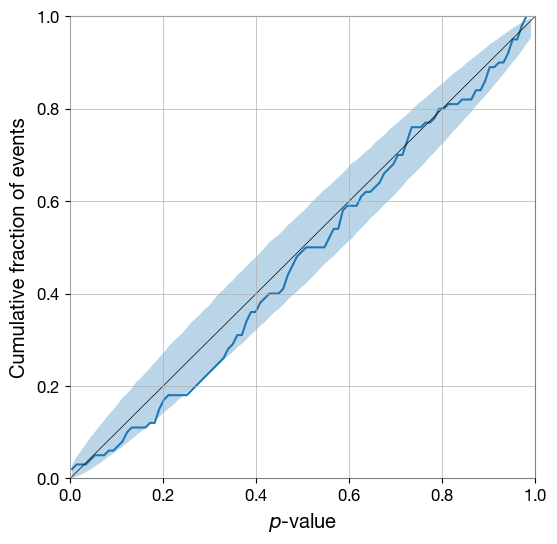

In [26]:
prob = 0.9

H,X = np.histogram(pvalues, bins=100, density=True)
p_lim_low = np.zeros_like(X)
p_lim_high = np.zeros_like(X)
for iX in range(len(X)):
    p = iX / len(X)
    p_lim_low[iX], p_lim_high[iX] = pvalue_interval(p, n_noise_real, prob)

fig, ax = plt.subplots(1,1, figsize=[6,6])
ax.plot(X[:-1], np.cumsum(H) / np.sum(H))
ax.fill_between(X, p_lim_low, p_lim_high, alpha=0.3)
# ax.plot(X, p_lim_low)
# ax.plot(X, p_lim_high)
ax.plot(np.array([0., 1.]), np.array([0., 1.]), c='k', lw=0.5)
ax.set_xlim(0., 1.)
ax.set_ylim(0., 1.)
ax.set_xlabel(r'$p$-value')
ax.set_ylabel(r'Cumulative fraction of events')

## Failing to mix well between modes

In [30]:
n_dim = 1

mean_val_1 = -5.
mean_val_2 = 5.
w_1 = 0.2
w_2 = 0.8

prior_range = [[-10., 10.]]

mean_1 = mean_val_1 + np.zeros(n_dim, dtype=float)
mean_2 = mean_val_2 + np.zeros(n_dim, dtype=float)
x_ini = np.zeros(n_dim) + mean_val

# Build artificially some positive-definite covariance
A = 2.*np.ones((n_dim, n_dim), dtype=float)
cov = np.dot(A.T, A)
invcov = np.linalg.inv(cov)
detcov = np.linalg.det(cov)

def loglikelihood(x):
    p_1 = normal_pdf(x, mean_1, invcov, normalized=False)
    p_2 = normal_pdf(x, mean_2, invcov, normalized=False)
    return np.log(w_1*p_1 + w_2*p_2)
def logprior(x):
    for i in range(n_dim):
        if (x[i] < prior_range[i][0] or prior_range[i][1] < x[i]):
            return -np.inf
    return 1.

# Arbitrary covariance for the proposal
B = 0.5 * np.ones((n_dim, n_dim), dtype=float)
cov_prop = np.dot(B.T, B)
proposal = normal_proposal(cov_prop)

sampler = MHMCMC(1, x_ini=x_ini, loglikelihood=loglikelihood, logprior=logprior, proposal=proposal, seed=1)

/tmp/ipykernel_32507/599085031.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lnL_arr[i] = loglikelihood(x_arr[i])


Text(0, 0.5, '$\\mathcal{L}$')

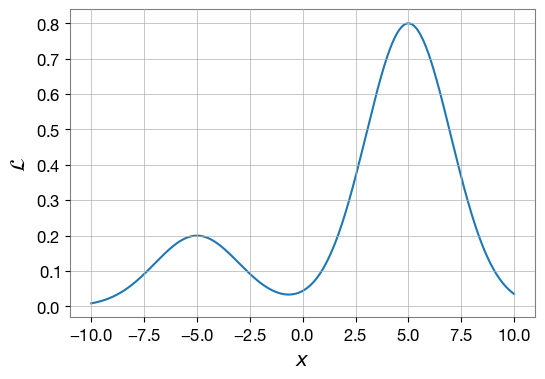

In [31]:
x_arr = np.linspace(-10., 10., 10000)
lnL_arr = np.zeros_like(x_arr)
for i in range(x_arr.shape[0]):
    lnL_arr[i] = loglikelihood(x_arr[i])
L_arr = np.exp(lnL_arr)

fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.plot(x_arr, L_arr)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$\mathcal{L}$')

In [35]:
sampler.run(10000)

100%|███████████████████████████████████████████████████████████████████████████████| 9999/9999 [00:01<00:00, 5672.48it/s]


Text(0.5, 0, '$x$')

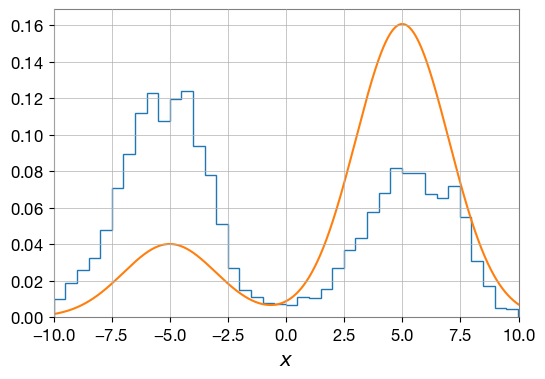

In [36]:
fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.hist(sampler.x.flatten(), histtype='step', density=True, bins=40);#, label=r'$n_{\rm dim}=' + str(n_dim) + '$', color=plotpalette[i])
ax.plot(x_arr, L_arr / np.sum(np.diff(x_arr) * L_arr[:-1]))
ax.set_xlim(-10., 10.)
ax.set_xlabel(r'$x$')

Text(0, 0.5, '$x$')

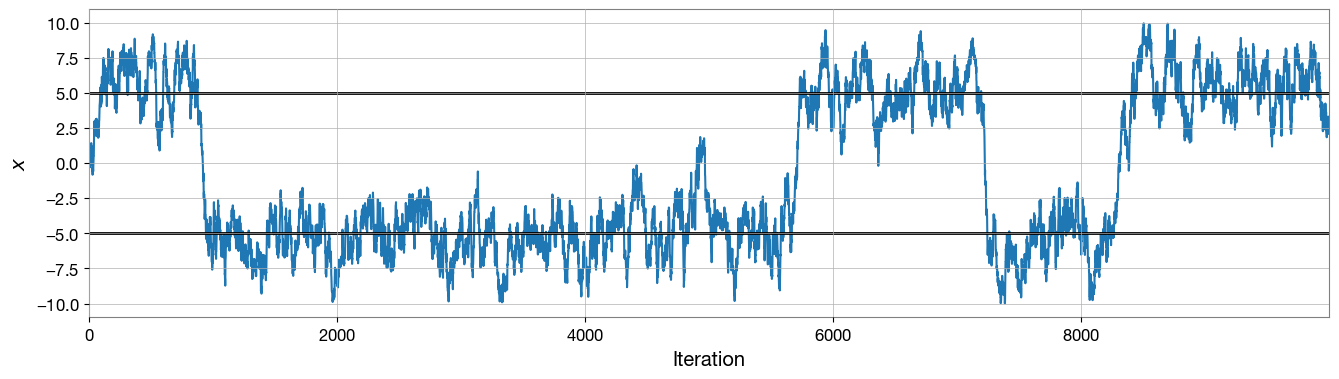

In [38]:
fig, ax = plt.subplots(1,1, figsize=[16,4])
ax.plot(sampler.x.flatten())
ax.set_xlim(0, sampler.x.shape[0]-1)
ax.axhline(mean_val_1, c='k', lw=2.)
ax.axhline(mean_val_2, c='k', lw=2.)
ax.set_xlabel(r'Iteration')
ax.set_ylabel(r'$x$')

## Failing to even find other modes

In [39]:
n_dim = 1

mean_val_1 = -5.
mean_val_2 = 5.
w_1 = 0.2
w_2 = 0.8

prior_range = [[-10., 10.]]

mean_1 = mean_val_1 + np.zeros(n_dim, dtype=float)
mean_2 = mean_val_2 + np.zeros(n_dim, dtype=float)
x_ini = np.zeros(n_dim) + mean_val

# Build artificially some positive-definite covariance
A = 0.5*np.ones((n_dim, n_dim), dtype=float)
cov = np.dot(A.T, A)
invcov = np.linalg.inv(cov)
detcov = np.linalg.det(cov)

def loglikelihood(x):
    p_1 = normal_pdf(x, mean_1, invcov, normalized=False)
    p_2 = normal_pdf(x, mean_2, invcov, normalized=False)
    return np.log(w_1*p_1 + w_2*p_2)
def logprior(x):
    for i in range(n_dim):
        if (x[i] < prior_range[i][0] or prior_range[i][1] < x[i]):
            return -np.infty
    return 1.

# Arbitrary covariance for the proposal
B = 0.5 * np.ones((n_dim, n_dim), dtype=float)
cov_prop = np.dot(B.T, B)
proposal = normal_proposal(cov_prop)

sampler = MHMCMC(1, x_ini=x_ini, loglikelihood=loglikelihood, logprior=logprior, proposal=proposal, seed=1)

Text(0, 0.5, '$\\mathcal{L}$')

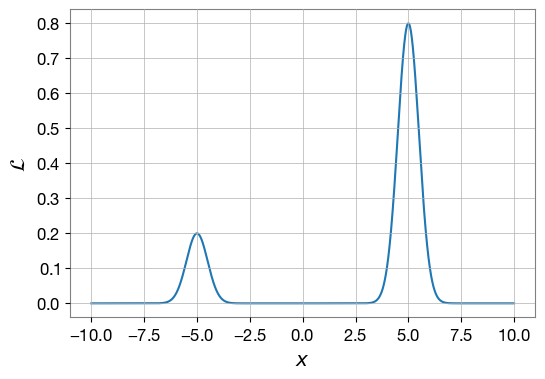

In [40]:
x_arr = np.linspace(-10., 10., 10000)
lnL_arr = np.zeros_like(x_arr)
for i in range(x_arr.shape[0]):
    lnL_arr[i] = loglikelihood(x_arr[i])
L_arr = np.exp(lnL_arr)

fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.plot(x_arr, L_arr)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$\mathcal{L}$')

In [41]:
sampler.run(10000)

100%|███████████████████████████████████████████████████████████████████████████████| 9999/9999 [00:01<00:00, 5665.87it/s]


Text(0.5, 0, '$x$')

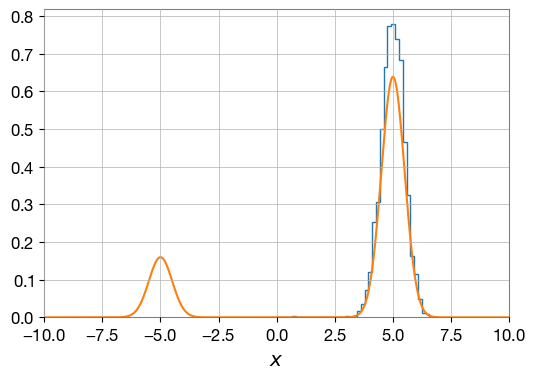

In [44]:
fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.hist(sampler.x.flatten(), histtype='step', density=True, bins=40);#, label=r'$n_{\rm dim}=' + str(n_dim) + '$', color=plotpalette[i])
ax.plot(x_arr, L_arr / np.sum(np.diff(x_arr) * L_arr[:-1]))
ax.set_xlim(-10., 10.)
ax.set_xlabel(r'$x$')

Text(0, 0.5, '$x$')

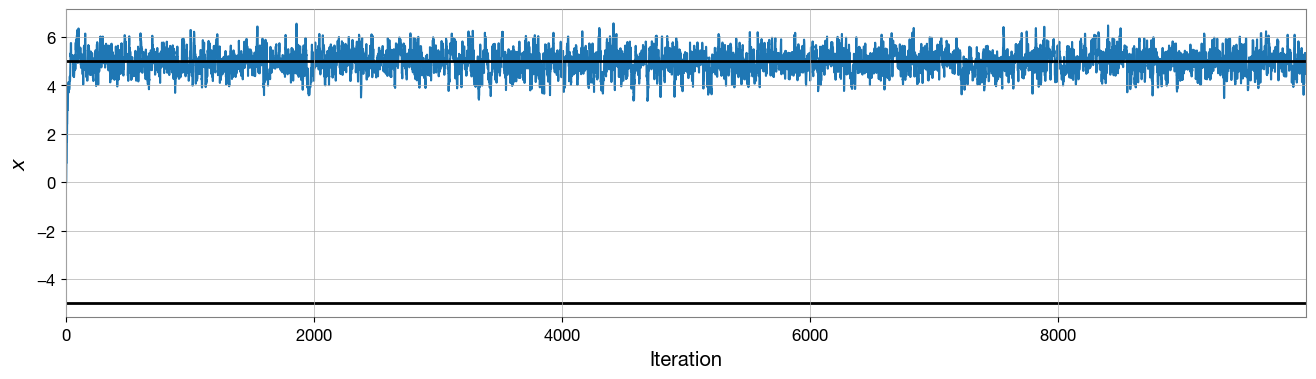

In [46]:
fig, ax = plt.subplots(1,1, figsize=[16,4])
ax.plot(sampler.x.flatten())
ax.set_xlim(0, sampler.x.shape[0]-1)
ax.axhline(mean_val_1, c='k', lw=2.)
ax.axhline(mean_val_2, c='k', lw=2.)
ax.set_xlabel(r'Iteration')
ax.set_ylabel(r'$x$')

## Parellel tempering to the rescue: Eryn

In [47]:
from eryn.ensemble import EnsembleSampler
from eryn.state import State
from eryn.prior import ProbDistContainer, uniform_dist
from eryn.utils import TransformContainer
from eryn.moves import GaussianMove, StretchMove, CombineMove
from eryn.utils.utility import groups_from_inds

In [48]:
# Params: M, q, A, Deltat, alpha
prior_range = np.array([
    [-10., 10.]])

In [49]:
# set prior limits
ndim = 1
priors_in = {i: uniform_dist(prior_range[i][0], prior_range[i][1]) for i in range(ndim)}
priors = ProbDistContainer(priors_in)

In [61]:
ndim = 1
nwalkers = 32
ntemps = 5
Tmax = 50
nsteps = 1000
burn = int(nsteps/2)

# fill kwargs dictionary
tempering_kwargs=dict(ntemps=ntemps, Tmax=Tmax)

# Starting positions
# randomize throughout prior
coords = priors.rvs(size=(ntemps, nwalkers,))

# initialize sampler
ensemble = EnsembleSampler(
    nwalkers,
    ndim,
    loglikelihood,
    priors,
    args=[],
    tempering_kwargs=tempering_kwargs
)

In [59]:
coords.shape

(5, 32, 1)

In [62]:
out = ensemble.run_mcmc(coords, nsteps, burn=0, progress=True, thin_by=1)

100%|████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:05<00:00, 173.83it/s]


In [63]:
samples = ensemble.get_chain()['model_0']
log_likelihoods = ensemble.get_log_like()
samples.shape, log_likelihoods.shape

((1000, 5, 32, 1, 1), (1000, 5, 32))

In [64]:
temp = 0

samples_flat = np.zeros(((nsteps - burn) * nwalkers, ndim), dtype=float)
for i in range(ndim):
    samples_flat[:,i] = np.ravel(samples[burn:,temp,:,0,i], order='F')
lnlike_flat = np.ravel(log_likelihoods[burn:,temp,:], order='F')

In [65]:
samples_flat.shape, lnlike_flat.shape

((16000, 1), (16000,))

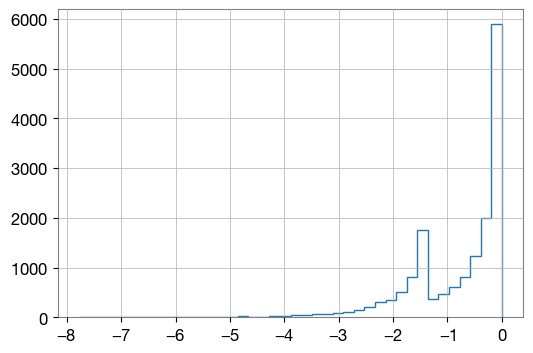

In [68]:
lnL_max = np.max(lnlike_flat)

fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.hist(lnlike_flat - lnL_max, histtype='step', bins=40);

Text(0.5, 0, '$x$')

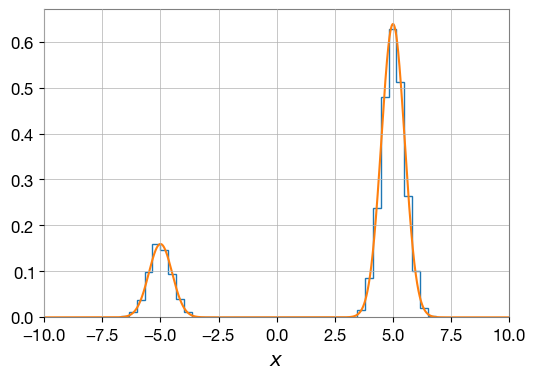

In [69]:
fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.hist(samples_flat, histtype='step', density=True, bins=40);#, label=r'$n_{\rm dim}=' + str(n_dim) + '$', color=plotpalette[i])
ax.plot(x_arr, L_arr / np.sum(np.diff(x_arr) * L_arr[:-1]))
ax.set_xlim(-10., 10.)
ax.set_xlabel(r'$x$')

Text(0, 0.5, '$x$')

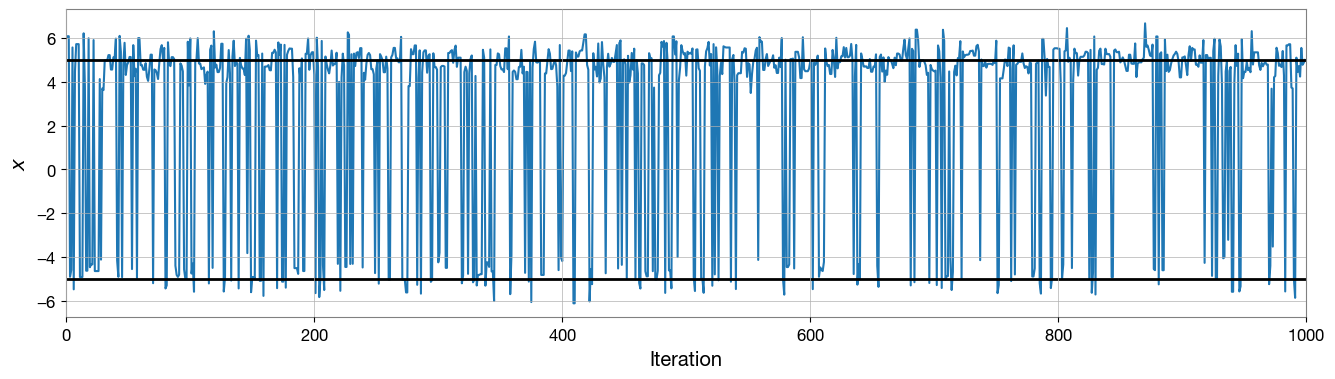

In [81]:
fig, ax = plt.subplots(1,1, figsize=[16,4])
itemp = 0
iwalker = 0
ax.plot(np.arange(nsteps), samples[:,itemp,iwalker,0,0].flatten())
ax.set_xlim(0, nsteps)
ax.axhline(mean_val_1, c='k', lw=2.)
ax.axhline(mean_val_2, c='k', lw=2.)
ax.set_xlabel(r'Iteration')
ax.set_ylabel(r'$x$')

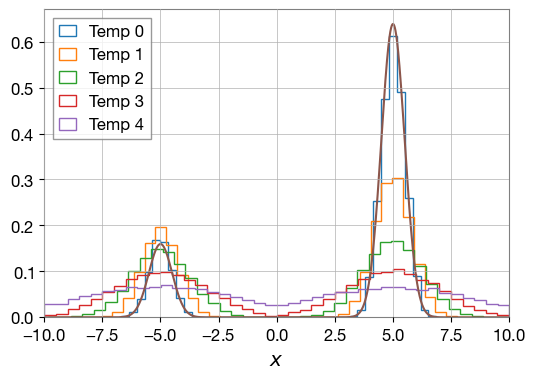

In [86]:
fig, ax = plt.subplots(1,1, figsize=[6,4])
for itemp in range(5):
    ax.hist(samples[:,itemp,:,0,0].flatten(), histtype='step', density=True, bins=40, label=r'Temp '+str(itemp));#, label=r'$n_{\rm dim}=' + str(n_dim) + '$', color=plotpalette[i])
ax.plot(x_arr, L_arr / np.sum(np.diff(x_arr) * L_arr[:-1]))
ax.set_xlim(-10., 10.)
ax.set_xlabel(r'$x$')
ax.legend()

# Part II: example parameter estimation for GW150914

## Setup: downloading strain data, evaluating PSD, data in the Fourier domain

Here we simply repeat setup steps from `tutorial_1`

In [89]:
from gwosc import datasets
from gwosc.datasets import find_datasets
from gwosc.datasets import event_gps

from gwpy.timeseries import TimeSeries

In [90]:
t_gps = event_gps('GW150914')
print(t_gps)

1126259462.4


In [91]:
H1_data = TimeSeries.read('./data/GW150914/H-H1_GWOSC_4KHZ_R1-1126259447-32.hdf5', format="hdf5.gwosc")
L1_data = TimeSeries.read('./data/GW150914/L-L1_GWOSC_4KHZ_R1-1126259447-32.hdf5', format="hdf5.gwosc")

In [92]:
# segment = (int(t_gps) - 16, int(t_gps) + 16)
# H1_data = TimeSeries.fetch_open_data('H1', *segment, verbose=True, cache=True)
# L1_data = TimeSeries.fetch_open_data('L1', *segment, verbose=True, cache=True)

In [93]:
times = np.asarray(H1_data.times).copy()
# New origin of times: middle of our data interval
t_center = times[len(times)//2]
times -= t_center
tevent = t_gps - t_center
strain_H1 = np.asarray(H1_data).copy()
strain_L1 = np.asarray(L1_data).copy() + 1e-18 # Strain is shifted by a constant, unknown why

dt = H1_data.dt.value
fs = 1./dt
dt, fs, len(times)

(np.float64(0.000244140625), np.float64(4096.0), 131072)

In [101]:
freqs_psd, psd_H1 = scipy.signal.welch(strain_H1, fs,  window='hann', nperseg=16384, scaling='density')
freqs_psd, psd_L1 = scipy.signal.welch(strain_L1, fs,  window='hann', nperseg=16384, scaling='density')

# We will use interpolations of the ASDs computed above for whitening:
psd_H1_interp = scipy.interpolate.interp1d(freqs_psd, psd_H1)
psd_L1_interp = scipy.interpolate.interp1d(freqs_psd, psd_L1)

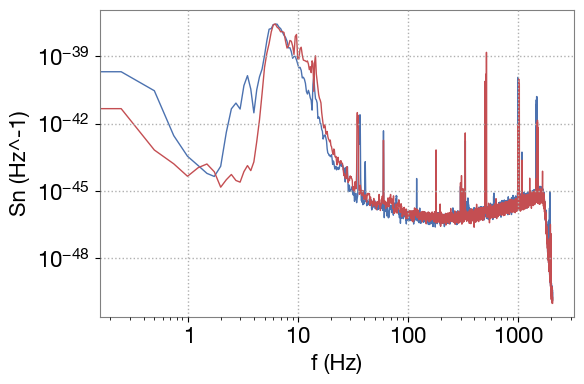

In [102]:
fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.loglog(freqs_psd, psd_H1, c=colors[0], lw=1)
ax.loglog(freqs_psd, psd_L1, c=colors[1], lw=1)

# ax.set_xlim([5., 2048.])
ax.set_xlabel(r'f (Hz)')
ax.set_ylabel(r'Sn (Hz^-1)')

fig.tight_layout()

In [106]:
# Data selected to be +-4s around the event
# _d for 'data' that we are going to actually use

n = 2**np.round(np.log2(8. / dt))
mask_d = ( -n//2*dt <= times) & (times < n//2*dt)
times_d = times[mask_d]
strain_H1_d = strain_H1[mask_d]
strain_L1_d = strain_L1[mask_d]

n, n*dt, len(times_d), [times_d[0], times_d[-1]]

(np.float64(32768.0),
 np.float64(8.0),
 32768,
 [np.float64(-4.0), np.float64(3.999755859375)])

In [107]:
# Tapering data at both ends
w = window_planck(times_d, times_d[0], times_d[-1], 0.5, 0.5)
strain_H1_tap = w * strain_H1_d
strain_L1_tap = w * strain_L1_d

In [108]:
# Data FD
freq_H1, strain_H1_fd = fft_positivef(times_d, strain_H1_tap)
freq_L1, strain_L1_fd = fft_positivef(times_d, strain_L1_tap)

df = freq_H1[1] - freq_H1[0]
df

np.float64(0.125)

In [109]:
# Frequency range for inner products
mask = (10. < freq_H1) & (freq_H1 < 1024.)
freq = freq_H1[mask]
freq.shape

(8111,)

## Signal model: A exp(i alpha) exp(-2i pi f Deltat) * h2-2(f)

We will reuse the simplified template model of `tutorial_1`: $A$ and $\alpha$ are an effective amplitude and phase encapsulating distance, inclination, phase, polarization, sky position, ...
$$ \tilde{h}_{\rm temp}(f) = A e^{i \alpha} e^{-2 i \pi f \Delta t} \tilde{h}_{2,-2}(f)$$

In [103]:
def PhenomXAS_LAL(freqs, M, q, chi1z, chi2z, dist, f_ref=100., phi_ref=0., Deltat=0.):
    
    Ms = M * lal.MTSUN_SI
    
    m1_SI = M * q/(1.+q) * lal.MSUN_SI
    m2_SI = M * 1./(1.+q) * lal.MSUN_SI
    
    dist_SI = (dist * 1e6 * lal.PC_SI)
    
    lal_params = lal.CreateDict()
    # NOTE: we set this to deactivate multibanding
    # lalsim.SimInspiralWaveformParamsInsertPhenomXHMThresholdMband(lal_params, 0)
    
    # Amplitude prefactor for physical units
#     amp0 = M * lal.MRSUN_SI * M * lal.MTSUN_SI / (dist * 1e6 * lal.PC_SI);

    # Input frequency sequence
    freqsSequence = lal.CreateREAL8Sequence(len(freqs))
    freqsSequence.data[:] = freqs[:]
    
    # Generate
    h22 = lalsimulation.SimIMRPhenomXASFrequencySequence(
        freqsSequence,
        m1_SI,
        m2_SI,
        chi1z,
        chi2z,
        dist_SI,
        phi_ref,
        f_ref,
        lal_params);

    # Extract data
    h2m2data = np.copy(h22.data.data)
    # NOTE: PhenomX FrequencySeries output is for frequencies ]-N/2, N/2] 
    # freq = deltaf * np.arange(-len(h22data)//2 + 1, len(h22data)//2 + 1)
    
    # Convention correction: no conjugation here, LAL convention (factor (-1)^l = 1 here anyway)
    # h22data = np.conj(h22data)
    
    # Add time shift by Deltat
    h2m2data *= np.exp(-2*1j*np.pi*Deltat*freqs)
        
    return freqs, h2m2data

In [104]:
def signal_h(freq, M, q, A, Deltat, alpha):
    m1 = M * q / (1+q)
    m2 = M * 1. / (1+q)
    dist = 1e3
    chi1 = 0.
    chi2 = 0.
    f, h2m2 = PhenomXAS_LAL(freq, M, q, chi1, chi2, dist, Deltat=Deltat)
    h2m2 *= A * np.exp(1j*alpha)
    return f, h2m2

In [110]:
f, h = signal_h(freq, 60., 1.5, 1., 0., np.pi/3)

The performance of the likelihood compuation is crucial for sampling, with our settings (8s of data only, low max frequency, very simple waveform) we get a good evaluation speed: 

In [111]:
%timeit f, h = signal_h(freq, 60., 1.5, 1., 0., np.pi/3)

2.53 ms ± 76.4 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


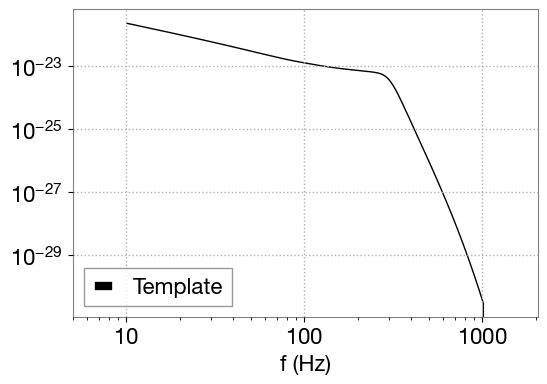

In [112]:
fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.loglog(f, np.abs(h), c='k', label=r'Template')

ax.set_xlim(5., 2048.)

ax.set_xlabel(r'f (Hz)')
ax.legend(loc='lower left')

## Setting up data, prior and likelihood

Recall that we the inner product intervening in the matched filter statistic and the likelihood is
$$ ( a | b ) = 4 \mathrm{Re} \int_{0}^{+\infty} df \; \frac{\tilde{a}^{*}(f)\tilde{b}(f)}{S_n(f)}$$
The likelihood is
$$ \ln\mathcal{L}(\theta) = -\frac{1}{2} (d - h(\theta) | d - h(\theta)) $$

The posterior that we want to sample from is
$$ p(\theta | d) \propto p(d | \theta) p(\theta) $$
for the priors, we take them flat for simplicity. Unphysical regions can be implemented by setting the prior there to 0 (in log, some large negative number).

In [113]:
psd_vals = psd_H1_interp(freq)
invpsd_vals = 1./psd_vals

data = strain_H1_fd[mask]

In [114]:
def prior_check(x, prior_bounds):
    if prior_bounds is None:
        return True
    else:
        # NOTE: the following (faster) raises 'list indices must be integers or slices, not tuple'
        # but seems to depend on the version of python/numpy ?
        # return np.all((prior_bounds[:,0] <= x) * (x <= prior_bounds[:,1]))
        return np.all([(prior_bounds[i][0]<=x[i] and x[i]<=prior_bounds[i][1]) for i in range(len(x))])

def lnprior(x, prior_bounds=None):
    if not prior_check(x, prior_bounds):
        return -1e99
    else:
        return 0.

In [115]:
def lnlike(x, prior_bounds=None):
    if not prior_check(x, prior_bounds):
        return -1e99
    else:
        M, q, A, Deltat, alpha = x
        _, h_vals = signal_h(freq, M, q, A, Deltat, alpha)
        # h_vals = h['amp'] * np.exp(1j * h['phase'])
        resid = h_vals - data
        integrand = np.real(resid * np.conj(resid)) * invpsd_vals
        return -1./2 * 4*df* np.sum((integrand[1:] + integrand[:-1]) / 2)

## Sampling with Eryn

We will use the sampler Eryn, an ensemble sampler MCMC with parallel-tempering.

We refer to the documentation of Eryn for more details: [Eryn](https://mikekatz04.github.io/Eryn/html/index.html)

In [116]:
from eryn.ensemble import EnsembleSampler
from eryn.state import State
from eryn.prior import ProbDistContainer, uniform_dist
from eryn.utils import TransformContainer
from eryn.moves import GaussianMove, StretchMove, CombineMove
from eryn.utils.utility import groups_from_inds

In [117]:
# Params: M, q, A, Deltat, alpha

list_params = ['M', 'q', 'A', 'Deltat', 'alpha']

prior_range = np.array([
    [65., 75.],
    [1., 2.],
    [0., 2.],
    [-1., 1.],
    [-np.pi, np.pi]])

In [118]:
# set prior limits
ndim = 5
priors_in = {i: uniform_dist(prior_range[i][0], prior_range[i][1]) for i in range(ndim)}
priors = ProbDistContainer(priors_in)

In [119]:
np.random.seed(1)

ndim = 5
nwalkers = 32
ntemps = 5
Tmax = 50
nsteps = 1000

# fill kwargs dictionary
tempering_kwargs=dict(ntemps=ntemps, Tmax=Tmax)

# Starting positions
# randomize throughout prior
coords = priors.rvs(size=(ntemps, nwalkers,))

# initialize sampler
ensemble = EnsembleSampler(
    nwalkers,
    ndim,
    lnlike,
    priors,
    args=[],
    kwargs={'prior_bounds': prior_range},
    tempering_kwargs=tempering_kwargs
)

In [120]:
# This run should take about 4-5 min
out = ensemble.run_mcmc(coords, nsteps, burn=0, progress=True, thin_by=1)

100%|█████████████████████████████████████████████████████████████████████████████████| 1000/1000 [04:35<00:00,  3.63it/s]


In [121]:
samples = ensemble.get_chain()['model_0']
log_likelihoods = ensemble.get_log_like()
samples.shape, log_likelihoods.shape

((1000, 5, 32, 1, 5), (1000, 5, 32))

In [122]:
# Output to file - note that Eryn has proper backends that also allow to resume a run, we do not do that here
np.save('./samples/gw150914_example_eryn_samples.npy', samples)
np.save('./samples/gw150914_example_eryn_log_likelihoods.npy', log_likelihoods)

### Loading results

In [16]:
samples = np.load('./samples/gw150914_example_eryn_samples.npy')
log_likelihoods = np.load('./samples/gw150914_example_eryn_log_likelihoods.npy')

In [123]:
# Formats:
# samples: (nsteps, ntemps, nwalkers, nleaves_max, ndim).
# log_likelihoods: (nsteps, ntemps, nwalkers).

nsteps, ntemps, nwalkers, nleaves_max, ndim = samples.shape

samples.shape, log_likelihoods.shape

((1000, 5, 32, 1, 5), (1000, 5, 32))

### A first look: with the full chains, no burn-in

Here we select the 0-temperature chain and plot the histogram of log-likelihood values, as well as the corner plot in all 5 parameters.

In [130]:
temp = 0

samples_flat_all = np.zeros(((nsteps) * nwalkers, ndim), dtype=float)
for i in range(ndim):
    samples_flat_all[:,i] = np.ravel(samples[:,temp,:,0,i], order='F')
lnlike_flat_all = np.ravel(log_likelihoods[:,temp,:], order='F')

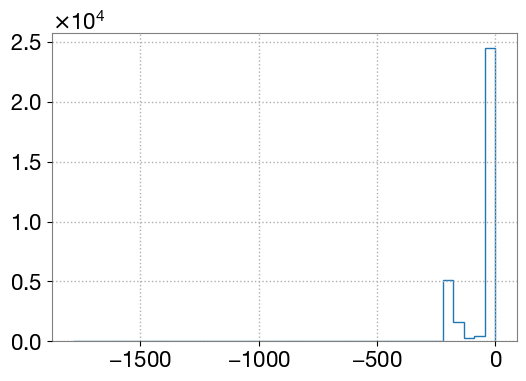

In [131]:
fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.hist(lnlike_flat_all - np.max(lnlike_flat_all), histtype='step', bins=40);

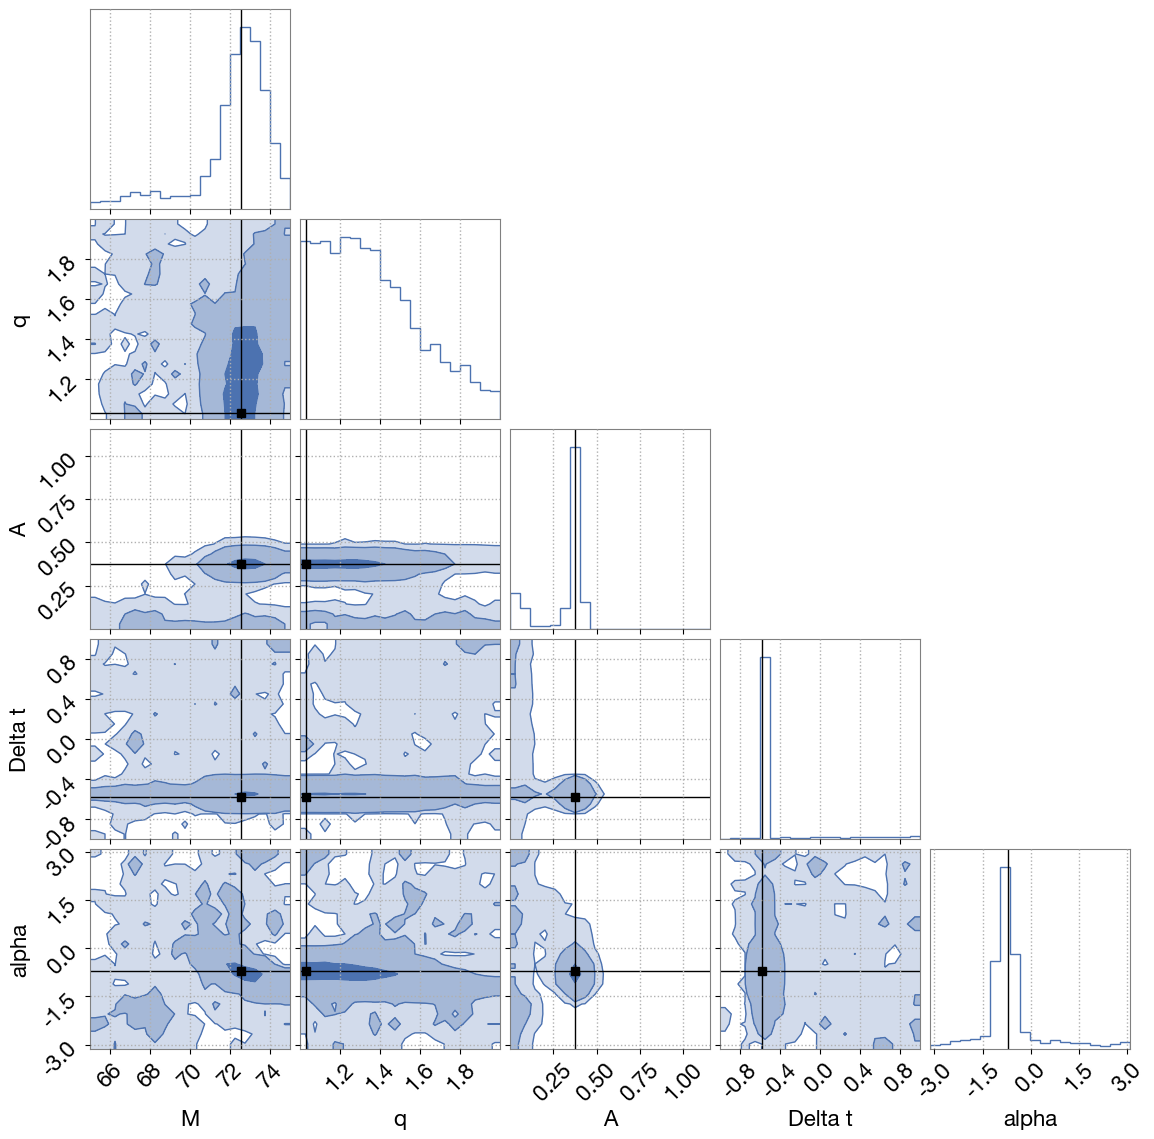

In [195]:
labels = [r'M', r'q', r'A', r'Delta t', r'alpha']
levels = 1.0 - np.exp(-0.5 * np.linspace(1.0, 3.0, num=3) ** 2)

corner.corner(samples_flat_all, plot_density=False, plot_datapoints=False, levels=levels, truths=x_max, truth_color='k', smooth=0.5, color='#4C72B0', fill_contours=True, labels=labels);

### Visualizing chains

We can visualize what the chains are doing, for every individual walker.
- Plot the trace of log-likelihood values for each walker as a function of the iteration number -- it is better to plot the difference from `lnL_max + 1`, in log scale after flipping the sign
- Plot the trace of the chain values in each of the parameters, as a function of the iteration number
- Which parameter is the harder to find (with our choice of prior ranges) ?
- Explanation of the behaviour of the chains in $A$ ?

In [205]:
# Formats (nleaves_max=1, ignore):
# samples: (nsteps, ntemps, nwalkers, nleaves_max, ndim).
# log_likelihoods: (nsteps, ntemps, nwalkers).

Text(0.5, 1.0, '')

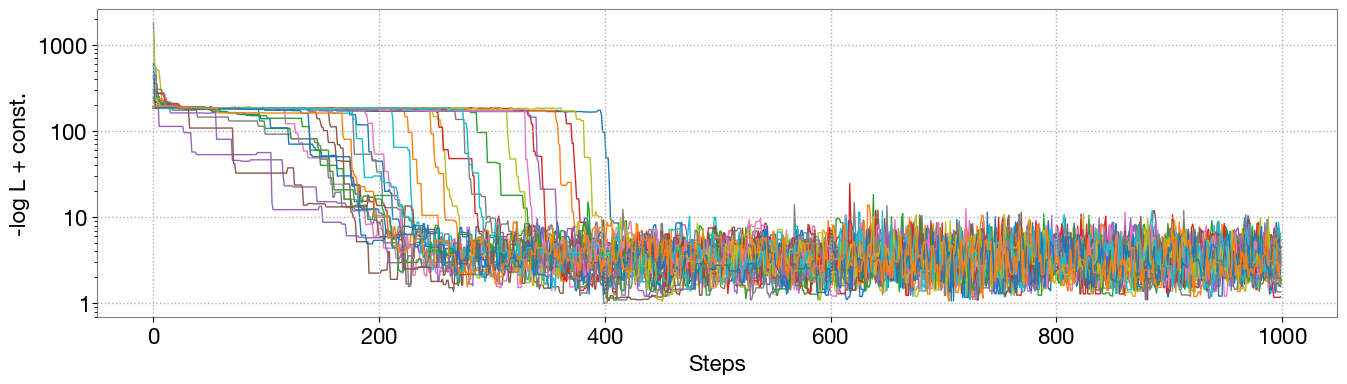

In [201]:
lnL_T0 = log_likelihoods[:,0,:]
lnL_max = np.max(lnL_T0)

fig, ax = plt.subplots(1,1, figsize=[16,4])
for i in range(lnL_T0.shape[1]):
    ax.plot(np.arange(lnL_T0.shape[0]), -(lnL_T0[:,i] - lnL_max - 1))

ax.set_yscale('log')
ax.set_xlabel(r'Steps')
ax.set_ylabel(r'-log L + const.')
ax.set_title(r'')

In [172]:
samples.shape

(1000, 5, 32, 1, 5)

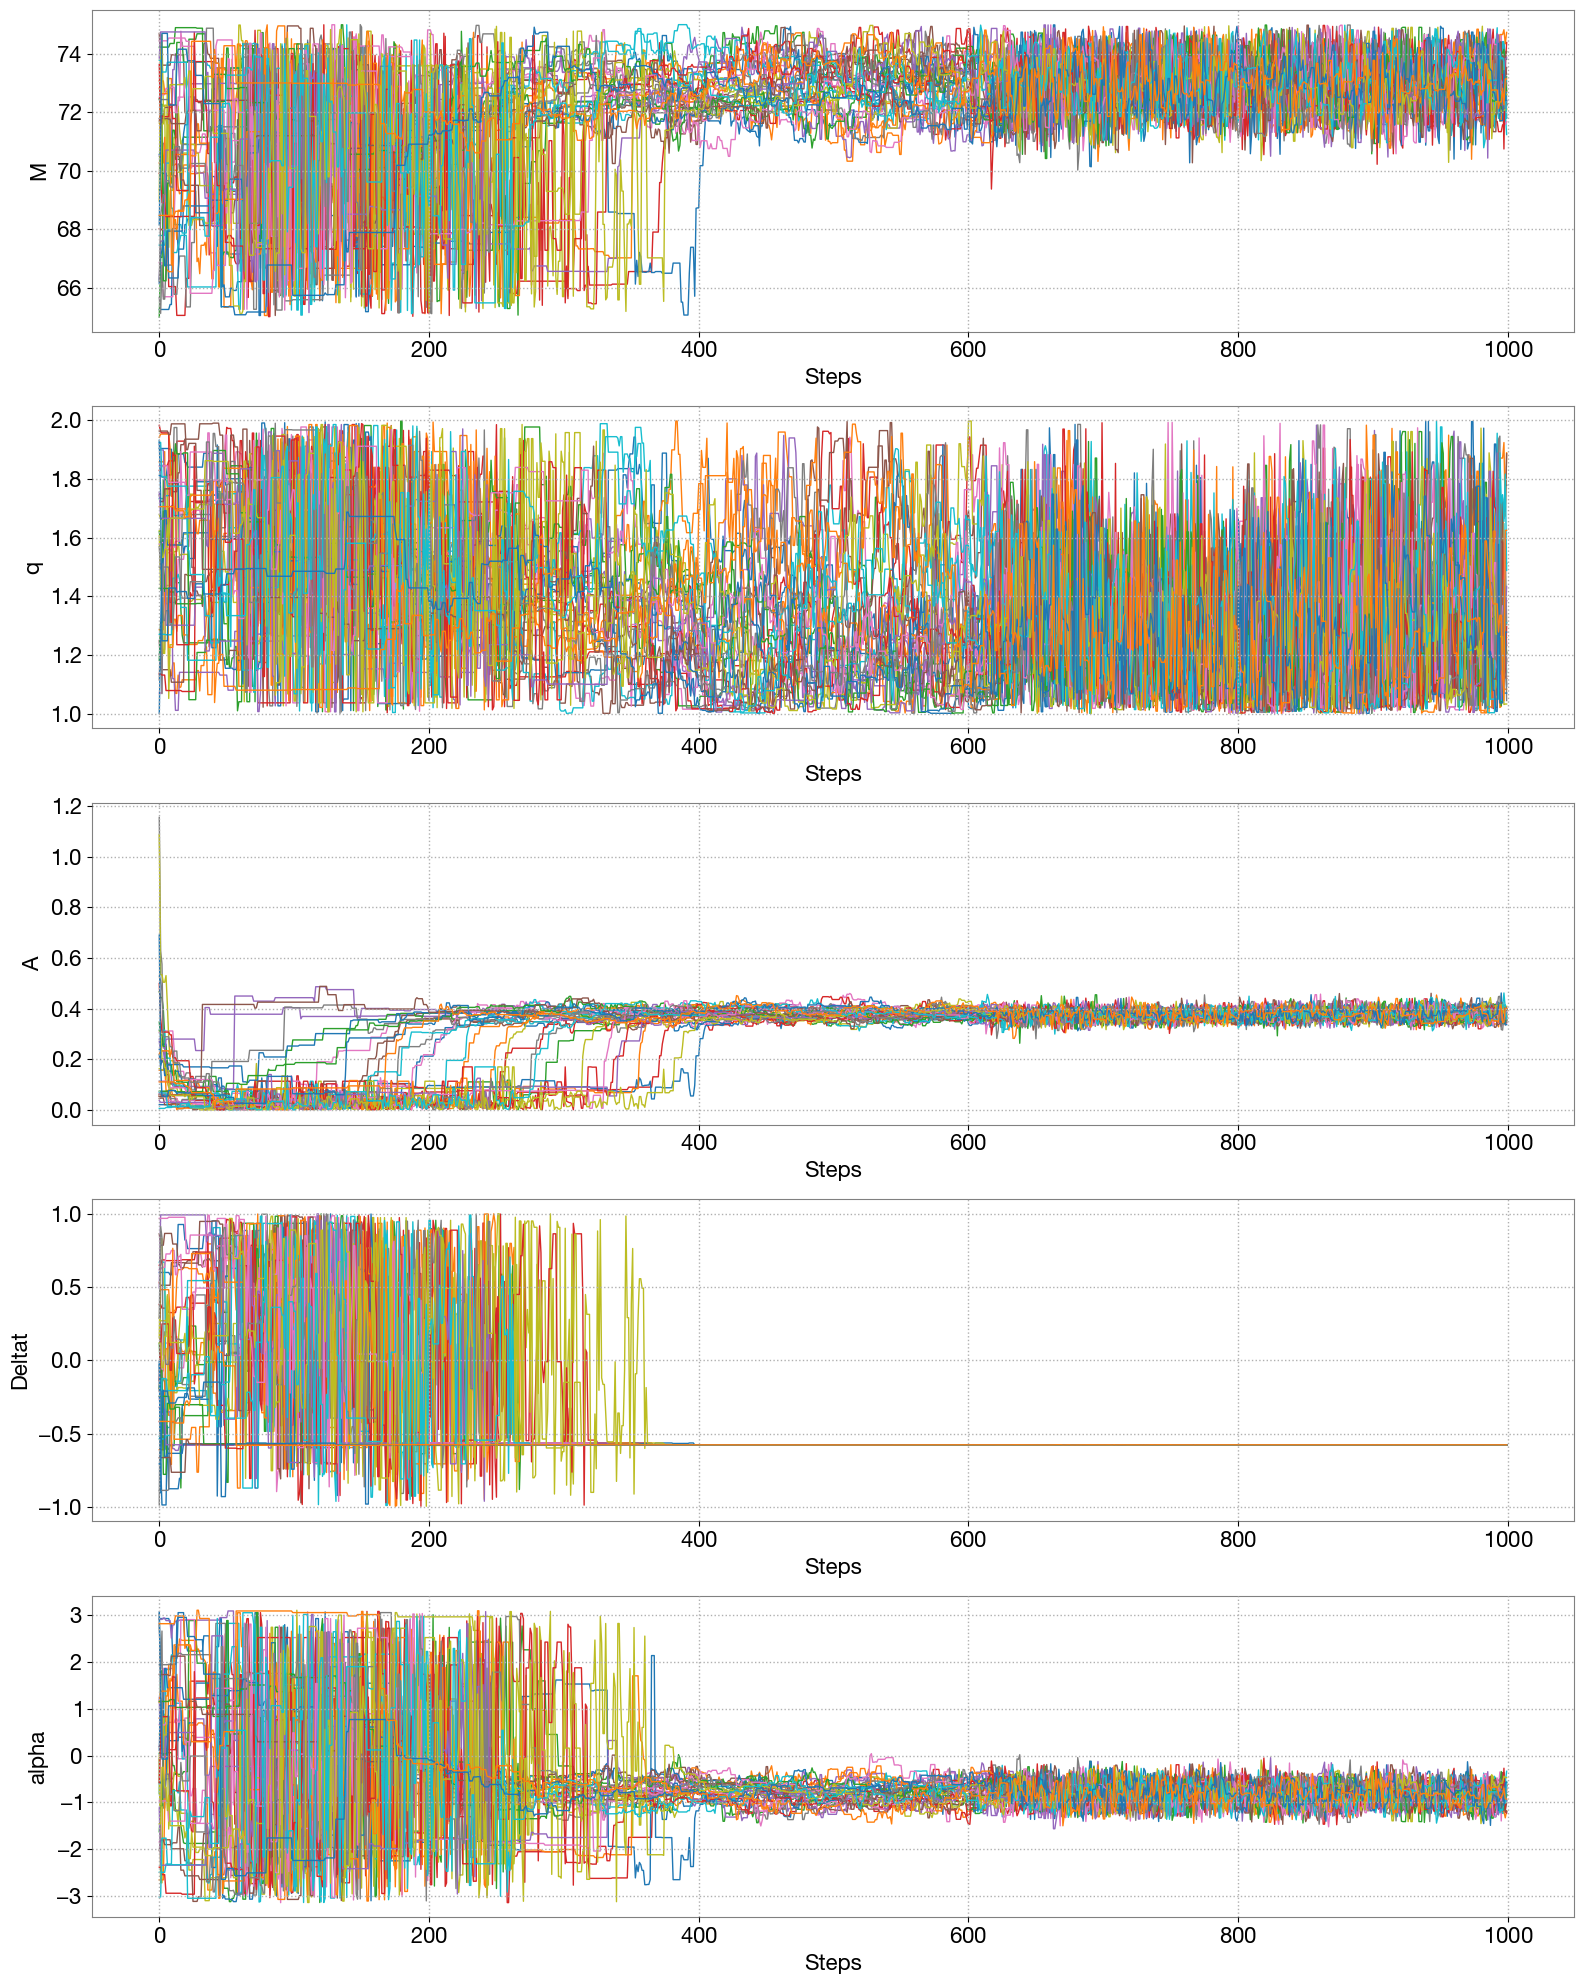

In [204]:
fig, axs = plt.subplots(5,1, figsize=[16,20])
for k in range(5):
    for i in range(samples.shape[2]):
        axs[k].plot(np.arange(samples.shape[0]), samples[:,0,i,:,k])

    axs[k].set_xlabel(r'Steps')
    axs[k].set_ylabel(r'' + list_params[k])

fig.tight_layout()

### Results after burn-in

We need to eliminate the initial part of the chains that correspond to a burn-in phase, where the samples are not representative of the final distribution. We will not get into the arcane of convergence diagnostics here -- we will simply cut the chains by eye.
- decide of a value of `burn`
- redo the histogram of the log-likelihood values for the cut chains
- redo the corner plot for the samples from the cut chains

In [129]:
# burn = ...

# temp = 0

# samples_flat = np.zeros(((nsteps - burn) * nwalkers, ndim), dtype=float)
# for i in range(ndim):
#     samples_flat[:,i] = np.ravel(samples[burn:,temp,:,0,i], order='F')
# lnlike_flat = np.ravel(log_likelihoods[burn:,temp,:], order='F')

In [196]:
burn = 600

temp = 0

samples_flat = np.zeros(((nsteps - burn) * nwalkers, ndim), dtype=float)
for i in range(ndim):
    samples_flat[:,i] = np.ravel(samples[burn:,temp,:,0,i], order='F')
lnlike_flat = np.ravel(log_likelihoods[burn:,temp,:], order='F')

In [197]:
samples_flat.shape, lnlike_flat.shape

((12800, 5), (12800,))

In [198]:
lnL_max = np.max(lnlike_flat)
imax = np.argmax(lnlike_flat)
x_max = samples_flat[imax, :]
x_max, lnL_max

(array([72.56396372,  1.02792874,  0.37700378, -0.57649735,
        -0.72063913]),
 np.float64(-13705.126002264898))

Text(0.5, 0, 'ln L - ln Lmax')

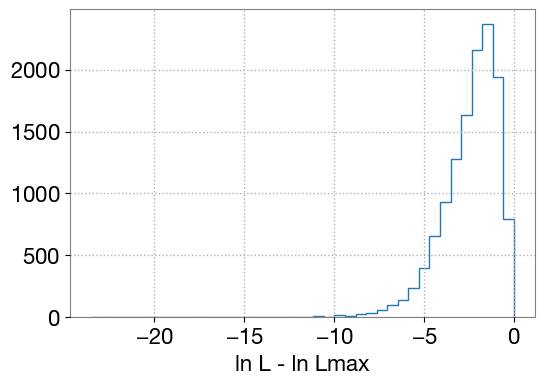

In [199]:
fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.hist(lnlike_flat - lnL_max, histtype='step', bins=40);
ax.set_xlabel(r'ln L - ln Lmax')

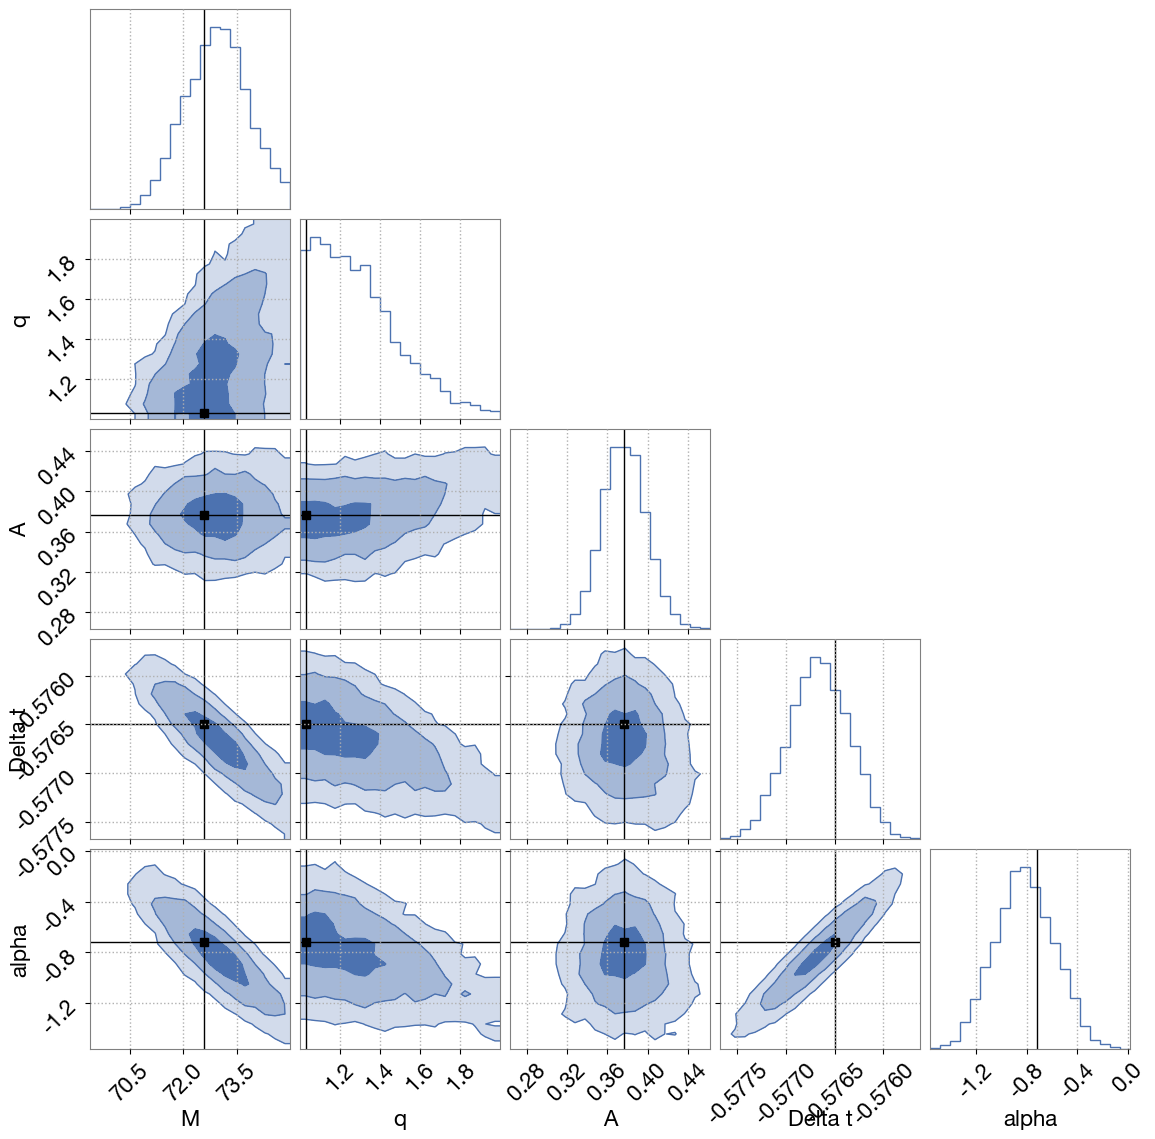

In [200]:
labels = [r'M', r'q', r'A', r'Delta t', r'alpha']
levels = 1.0 - np.exp(-0.5 * np.linspace(1.0, 3.0, num=3) ** 2)

corner.corner(samples_flat, plot_density=False, plot_datapoints=False, levels=levels, truths=x_max, truth_color='k', smooth=0.5, color='#4C72B0', fill_contours=True, labels=labels);

## Run PE - Bilby

In [8]:


class SimpleGaussianLikelihood(bilby.Likelihood):
    def __init__(self, data):
        """
        A very simple Gaussian likelihood

        Parameters
        ----------
        data: array_like
            The data to analyse
        """
        super().__init__(parameters={"mu": None, "sigma": None})
        self.data = data
        self.N = len(data)

    def log_likelihood(self):
        mu = self.parameters["mu"]
        sigma = self.parameters["sigma"]
        res = self.data - mu
        return -0.5 * (
            np.sum((res / sigma) ** 2) + self.N * np.log(2 * np.pi * sigma**2)
        )

data =  bilby.core.utils.random.rng.normal(3, 4, 100)

likelihood = SimpleGaussianLikelihood(data)
priors = dict(
    mu=bilby.core.prior.Uniform(0, 5, "mu"),
    sigma=bilby.core.prior.Uniform(0, 10, "sigma"),
)

# And run sampler
result = bilby.run_sampler(
    likelihood=likelihood,
    priors=priors,
    sampler="dynesty",
    nlive=1000,
    outdir='./samples/',
    label='test',
    save=False,
)
result.plot_corner()

12:15 bilby INFO    : Running for label 'test', output will be saved to './samples/'
12:15 bilby INFO    : Analysis priors:
12:15 bilby INFO    : mu=Uniform(minimum=0, maximum=5, name='mu', latex_label='mu', unit=None, boundary=None)
12:15 bilby INFO    : sigma=Uniform(minimum=0, maximum=10, name='sigma', latex_label='sigma', unit=None, boundary=None)
12:15 bilby INFO    : Analysis likelihood class: <class '__main__.SimpleGaussianLikelihood'>
12:15 bilby INFO    : Analysis likelihood noise evidence: nan
12:15 bilby INFO    : Single likelihood evaluation took 7.697e-05 s
12:15 bilby INFO    : Using sampler Dynesty with kwargs {'nlive': 1000, 'bound': 'live', 'sample': 'act-walk', 'periodic': None, 'reflective': None, 'update_interval': 600, 'first_update': None, 'npdim': None, 'rstate': None, 'queue_size': 1, 'pool': None, 'use_pool': None, 'live_points': None, 'logl_args': None, 'logl_kwargs': None, 'ptform_args': None, 'ptform_kwargs': None, 'gradient': None, 'grad_args': None, 'grad_

ModuleNotFoundError: No module named 'numpy._core'

In [6]:
bilby.run_sampler?

Signature:
bilby.run_sampler(
    likelihood,
    priors=None,
    label='label',
    outdir='outdir',
    sampler='dynesty',
    use_ratio=None,
    injection_parameters=None,
    conversion_function=None,
    plot=False,
    default_priors_file=None,
    clean=None,
    meta_data=None,
    save=True,
    gzip=False,
    result_class=None,
    npool=1,
    **kwargs,
)
Docstring:
The primary interface to easy parameter estimation

Parameters
likelihood: `bilby.Likelihood`
    A `Likelihood` instance
priors: `bilby.PriorDict`
    A PriorDict/dictionary of the priors for each parameter - missing
    parameters will use default priors, if None, all priors will be default
label: str
    Name for the run, used in output files
outdir: str
    A string used in defining output files
sampler: str, Sampler
    The name of the sampler to use - see
    `bilby.sampler.get_implemented_samplers()` for a list of available
    samplers.
    Alternatively a Sampler object can be passed
use_ratio: bool (

## Run PE - ptemcee

In [22]:
# Params: M, q, A, Deltat, alpha
prior_range = np.array([
    [50., 80.],
    [1., 2.],
    [0., 2.],
    [-1., 1.],
    [-np.pi, np.pi]])

In [32]:
ndim = 5
nwalkers = 64
ntemps = 5
Tmax = 100
niter = 1000
burn_in = int(niter/2)

datadir = './samples/'
name = 'gw150914_example'

# Initialization: draw from prior
xini = np.zeros((ntemps,nwalkers,ndim), dtype=float)
# Uniform f0, fdot0, amp, phi0, lambd, psi
for i in range(5):
    xini[:,:,i] = np.random.uniform(low=prior_range[i,0], high=prior_range[i,1], size=(ntemps,nwalkers))

# Temperatures
betas = ptemcee.sampler.make_ladder(ndim, ntemps=ntemps, Tmax=Tmax)

# Sampler
sampler = ptemcee.sampler.Sampler(nwalkers, ndim, lnlike, lnprior, logl_kwargs=[], logp_kwargs={'prior_bounds': prior_range}, betas=betas, adaptive=True, list_param_wrap=[None, None, None, None, [-np.pi, np.pi]])
chain = sampler.chain(xini)

# Initial likelihood values
lnLvals_ini = np.zeros((ntemps,nwalkers), dtype=float)
for i in range(ntemps):
    for j in range(nwalkers):
        lnLvals_ini[i,j] = lnlike(xini[i,j,:])

In [33]:
%time _ = chain.run(niter)

CPU times: user 13min 45s, sys: 2.62 s, total: 13min 48s
Wall time: 13min 48s


In [34]:
chain_unfold = np.transpose(chain.x[:,0,:,:], axes=(1,0,2))
# Same format without ndim for like and post values
lnlikevals = np.transpose(chain.logl[:,0,:], axes=(1,0))
lnpostvals = np.transpose(chain.logP[:,0,:], axes=(1,0))

thin_len = 1
n_fixed = 0
n_out = nwalkers * ((niter-burn_in-1) // thin_len + 1)
chain_processed = np.zeros((n_out, ndim + n_fixed), dtype=float)
for i in range(ndim):
#     i_out = list_params.index(infer_params[i])
    chain_processed[:,i] = np.ravel(chain_unfold[:,burn_in::thin_len,i],
                                        order='F')
lnlike_processed = np.ravel(lnlikevals[:,burn_in::thin_len], order='F')

# Output to file
np.save(datadir + 'chain_unfold_' + name + '.npy', chain_unfold)
np.save(datadir + 'lnlikevals_' + name + '.npy', lnlikevals)
np.save(datadir + 'chain_processed_' + name + '.npy', chain_processed)
np.save(datadir + 'lnlike_processed_' + name + '.npy', lnlike_processed)

In [148]:
# array([ 7.32045084e+01,  1.32900290e+00,  3.94760472e-01,  4.27858963e-01,
#         -5.70273657e-02]),
#  -30730.802799080564,

lnlike(np.array([ 7.32045084e+01,  1.32900290e+00,  3.94760472e-01,  4.27858963e-01,
        -5.70273657e-02]))

np.float64(-30731.539182743567)

In [48]:
%timeit lnlike(xini[0,0,:])

2.32 ms ± 65.9 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


### Results

In [35]:
datadir = './samples/'
name = 'gw150914_example'

chain_unfold = np.load(datadir + 'chain_unfold_' + name + '.npy')
lnlikevals = np.load(datadir + 'lnlikevals_' + name + '.npy')
chain_processed = np.load(datadir + 'chain_processed_' + name + '.npy')
lnlike_processed = np.load(datadir + 'lnlike_processed_' + name + '.npy')

In [36]:
chain_unfold.shape

(64, 1000, 5)

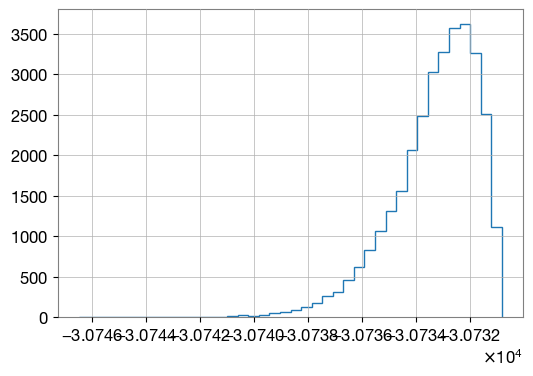

In [38]:
fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.hist(lnlike_processed, histtype='step', bins=40);

Text(0.5, 1.0, '')

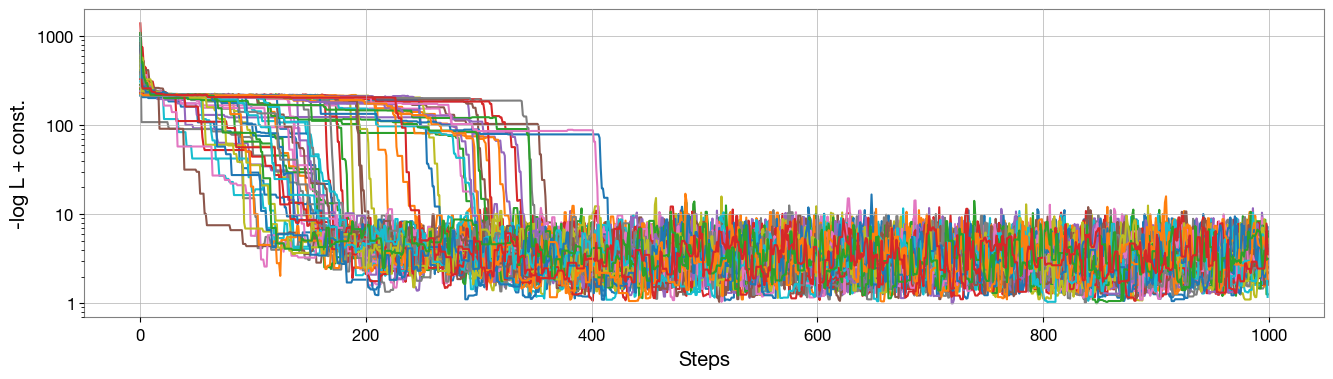

In [41]:
lnL_max = np.max(lnlike_processed)

fig, ax = plt.subplots(1,1, figsize=[16,4])
for i in range(lnlikevals.shape[0]):
    ax.plot(np.arange(lnlikevals.shape[1]), -(lnlikevals[i] - lnL_max - 1))

ax.set_yscale('log')
ax.set_xlabel(r'Steps')
ax.set_ylabel(r'-log L + const.')
ax.set_title(r'')

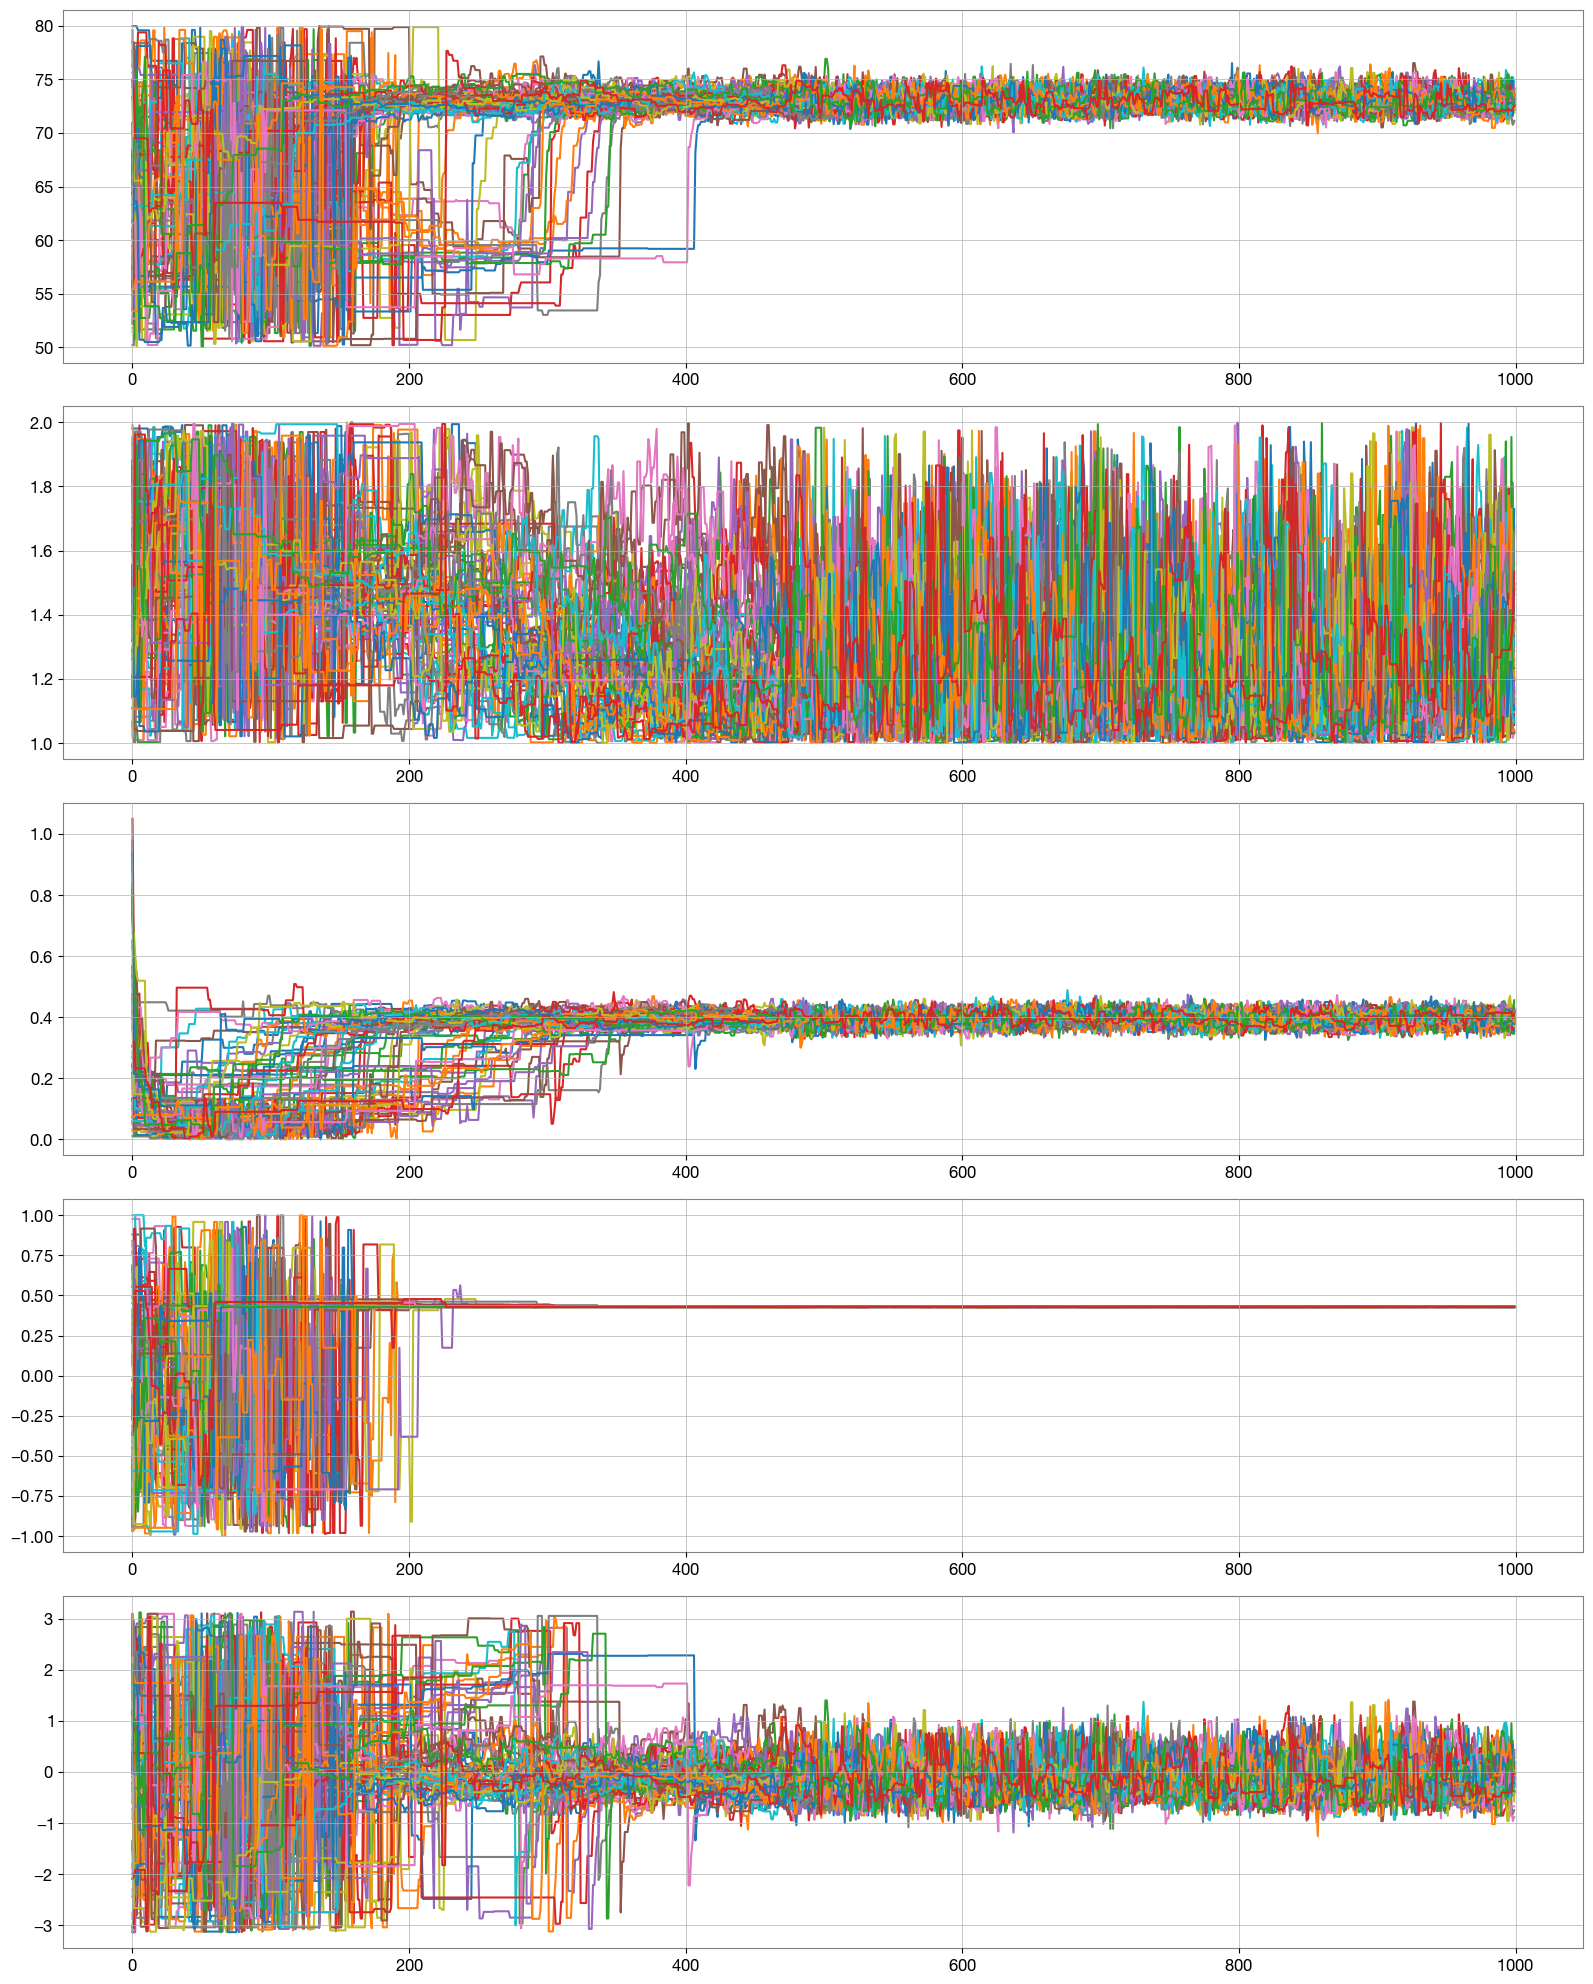

In [43]:
i = 0
pstr = 'M'

fig, axs = plt.subplots(5,1, figsize=[16,20])
for k in range(5):
    for i in range(lnlikevals.shape[0]):
        axs[k].plot(np.arange(lnlikevals.shape[1]), chain_unfold[i,:,k])

    ax.set_xlabel(r'Steps')
    # ax.set_ylabel(r'$-\ln \mathcal{L} + \mathrm{const.}$')
#     ax.set_title(r'')

fig.tight_layout()

In [44]:
lnlike_processed.shape, chain_processed.shape

((32000,), (32000, 5))

In [45]:
lnL_max = np.max(lnlike_processed)

imax = np.argmax(np.max(lnlike_processed))
x_max = chain_processed[imax]
x_max, lnL_max, len(freq)

(array([72.0409236 ,  1.25386116,  0.38852848,  0.42810148,
        -0.40978564]),
 np.float64(-30730.8138006195),
 32447)

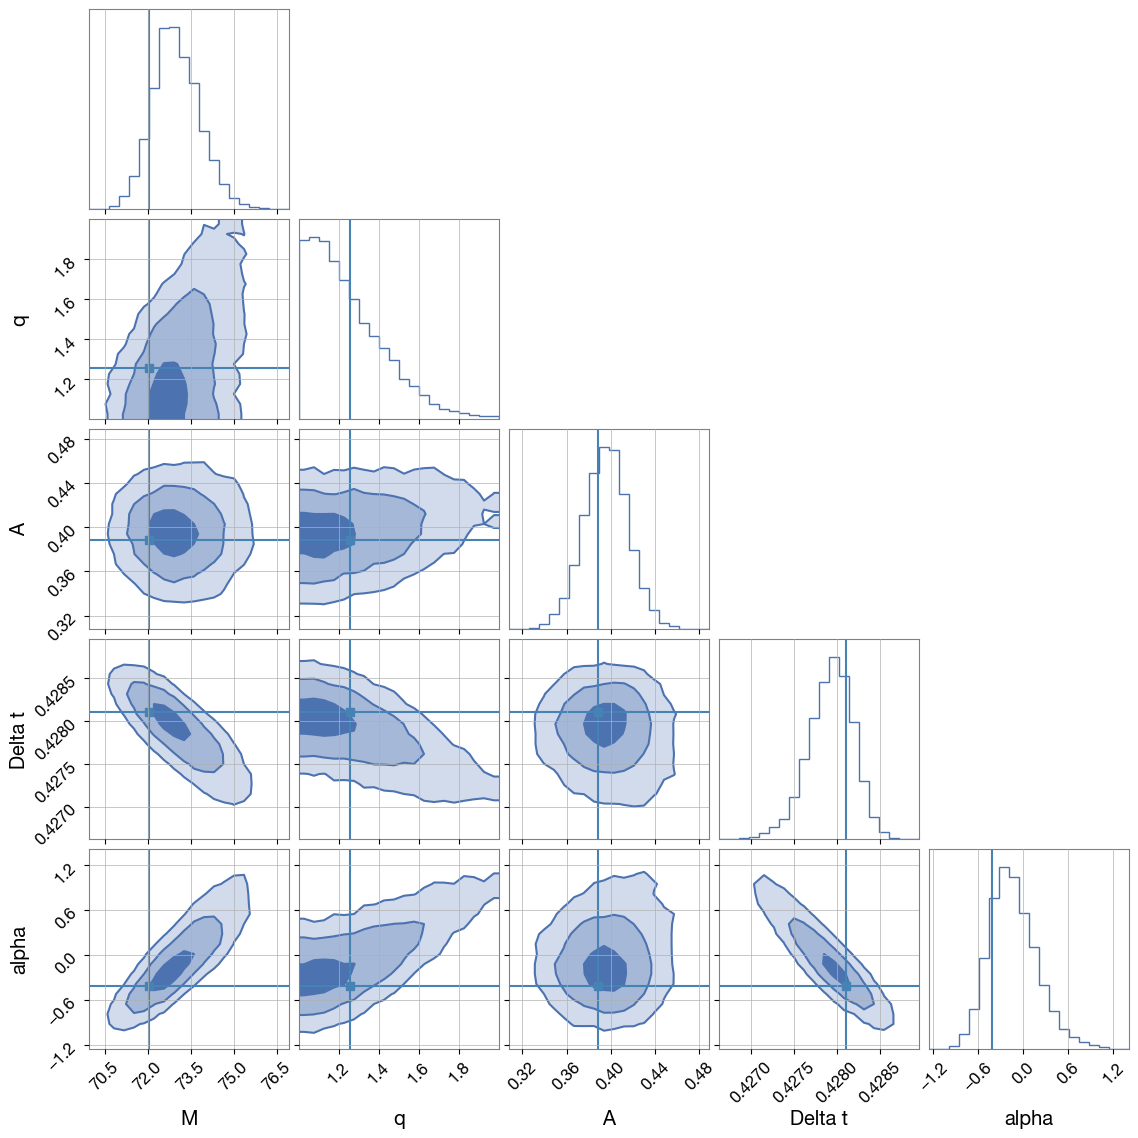

In [46]:
labels = [r'M', r'q', r'A', r'Delta t', r'alpha']
levels = 1.0 - np.exp(-0.5 * np.linspace(1.0, 3.0, num=3) ** 2)

corner.corner(chain_processed, truths=x_max, plot_density=False, plot_datapoints=False, levels=levels, smooth=0.5, color='#4C72B0', fill_contours=True, labels=labels);

## Waveform for max likelihood

Here we simply repeat the conditioning steps of `tutorial_1.ipynb` inorder to visualize the whitened-band passed max-liklihood template against data.

In [181]:
# Data whitened after band-passing

f_d = freq_H1
w_bp = window_planck(f_d, 10., 512., 10., 64.)

strain_H1_fd_wbp = w_bp * np.sqrt(2*df / psd_H1_interp(f_d)) * strain_H1_fd
strain_L1_fd_wbp = w_bp * np.sqrt(2*df / psd_L1_interp(f_d)) * strain_L1_fd

_, strain_H1_td_wbp = ifft_positivef(f_d, strain_H1_fd_wbp, real=True, tstart=times_d[0])
_, strain_L1_td_wbp = ifft_positivef(f_d, strain_L1_fd_wbp, real=True, tstart=times_d[0])

In [182]:
M_max, q_max, A_max, Deltat_max, alpha_max = x_max
x_max

array([72.56396372,  1.02792874,  0.37700378, -0.57649735,
       -0.72063913])

In [184]:
f_max, h_max = signal_h(freq, M_max, q_max, A_max, Deltat_max, alpha_max)

In [185]:
mask_h = (freq[0] <= f_d) & (f_d <= freq[-1])

def htemplate_td(M, q, A, Deltat, alpha):
    f, h = signal_h(freq, M, q, A, Deltat, alpha)
    w_ifft = window_planck(f_d, freq[0], freq[-1], 5., 128.)
    h_fd = np.zeros_like(f_d, dtype=complex)
    h_fd[mask_h] = w_ifft[mask_h] * h
    return ifft_positivef(f_d, h_fd, real=True, tstart=times_d[0])
    
def htemplate_wbp_td(M, q, A, Deltat, alpha):
    f, h = signal_h(freq, M, q, A, Deltat, alpha)
    w_ifft = window_planck(f_d, freq[0], freq[-1], 5., 128.)
    h_fd = np.zeros_like(f_d, dtype=complex)
    h_fd[mask_h] = w_ifft[mask_h] * h
    h_wbp_fd =  np.sqrt((2 * df) / psd_H1_interp(f_d)) * h_fd 
    return ifft_positivef(f_d, h_wbp_fd, real=True, tstart=times_d[0])

In [186]:
t_max, h_max_td = htemplate_td(M_max, q_max, A_max, Deltat_max, alpha_max)
t_max, h_max_wbp = htemplate_wbp_td(M_max, q_max, A_max, Deltat_max, alpha_max)

Text(0.5, 0, 't (s)')

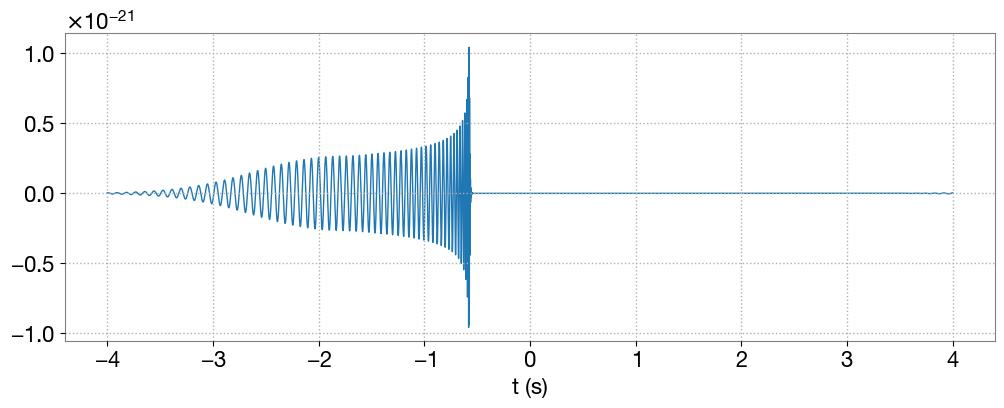

In [187]:
fig, ax = plt.subplots(1,1, figsize=[12,4])
ax.plot(t_max, h_max_td)
ax.set_xlabel(r't (s)')

Text(0.5, 0, 't (s)')

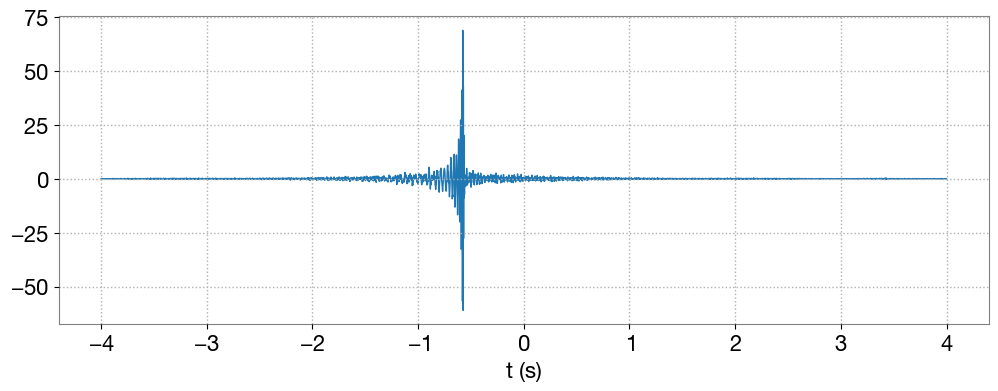

In [188]:
fig, ax = plt.subplots(1,1, figsize=[12,4])
ax.plot(t_max, h_max_wbp)
ax.set_xlabel(r't (s)')

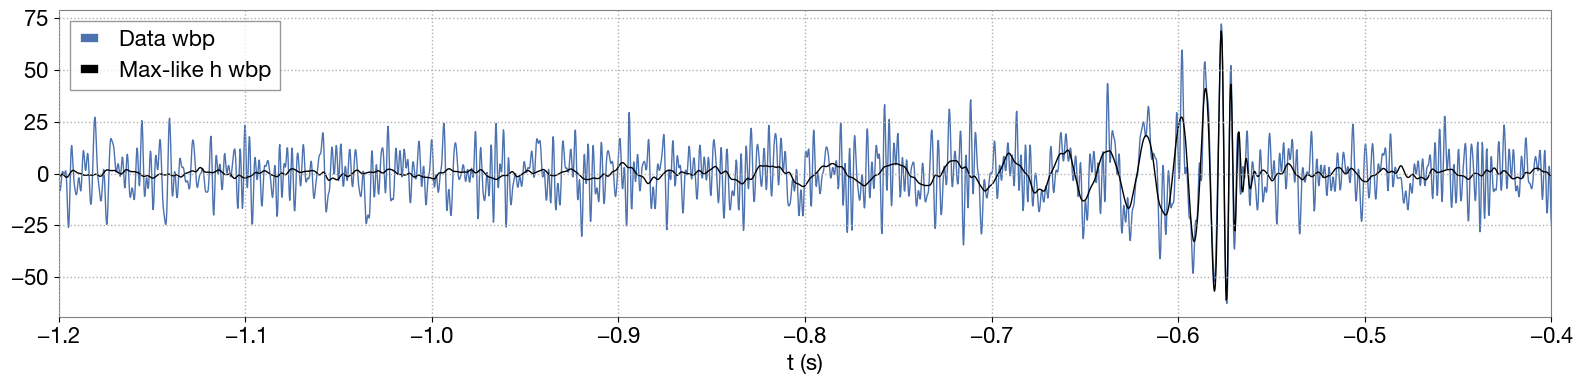

In [190]:
fig, ax = plt.subplots(1,1, figsize=[16,4])
ax.plot(times_d, strain_H1_td_wbp, c=colors[0], label=r'Data wbp')
ax.plot(times_d, h_max_wbp, c='k', label=r'Max-like h wbp')

ax.set_xlim([-1.2, -0.4])
ax.set_xlabel(r't (s)')
ax.legend(loc='upper left')

fig.tight_layout()

Here we visualize the whitened-band wavforms for each template in our posteriors, represented as a confidence interval at each time (we would also have plotted multiple lines, one per samples). This would be the predictive posterior for the waveform itself.

In [191]:
n_rand = 1000
inds = np.random.choice(range(len(samples_flat)), size=n_rand, replace=False)

h_wbp_td_all = np.zeros((len(times_d), n_rand), dtype=float)
for i in tqdm(range(n_rand)):
    M, q, A, Deltat, alpha = samples_flat[inds[i]]
    _, h_wbp_td_vals = htemplate_wbp_td(M, q, A, Deltat, alpha)
    h_wbp_td_all[:,i] = h_wbp_td_vals

100%|████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:05<00:00, 199.24it/s]


In [192]:
qs = np.array([0.025, 0.16, 0.5, 0.84, 0.975])

h_wbp_td_quantiles = np.quantile(h_wbp_td_all, qs, axis=1)
h_wbp_td_quantiles.shape

(5, 32768)

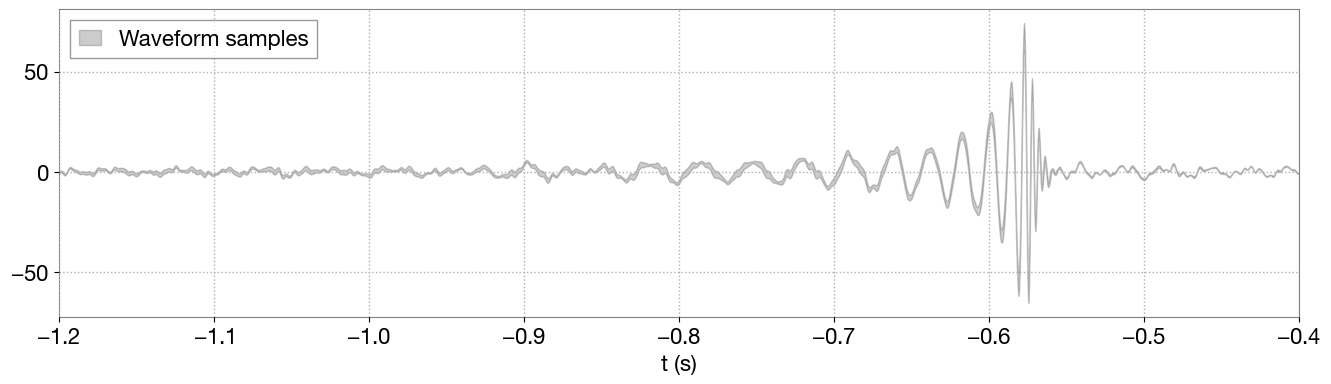

In [194]:
# NOTE: 2sigma waveform reconstruction is very narrow

trange = [-1.2, -0.4]

fig, ax = plt.subplots(1,1, figsize=[16,4])
# ax.plot(times_d, strain_H1_td_wbp, c=colors[0])
# ax.plot(times_d, hmax_wbp, c='k')
ax.fill_between(times_d, h_wbp_td_quantiles[0], h_wbp_td_quantiles[4], color=['k'], alpha=0.2, label='Waveform samples')

ax.set_xlim(trange)
ax.set_xlabel(r't (s)')
ax.legend(loc='upper left')

# Part III: simplified parameter estimation

## Visualizing the likelihood

In [144]:
list_params = ['M', 'q', 'A', 'Deltat', 'alpha']
npt = 400
lnlike_vals = {}
param_vals = {}

In [154]:
param = 'M'
width = 10.

i_param = list_params.index(param)
param_vals[param] = x_max[i_param] + np.linspace(-width, width, npt)

lnlike_vals[param] = np.zeros(npt, dtype=float)
for i in tqdm(range(npt)):
    x = x_max.copy()
    x[i_param] = param_vals[param][i]
    lnlike_vals[param][i] = lnlike(x)

100%|██████████████████████████████████████████████████████████████████████████████████| 400/400 [00:01<00:00, 354.27it/s]


In [155]:
param = 'q'

i_param = list_params.index(param)
param_vals[param] = np.linspace(1., 2., npt)

lnlike_vals[param] = np.zeros(npt, dtype=float)
for i in tqdm(range(npt)):
    x = x_max.copy()
    x[i_param] = param_vals[param][i]
    lnlike_vals[param][i] = lnlike(x)

100%|██████████████████████████████████████████████████████████████████████████████████| 400/400 [00:01<00:00, 358.56it/s]


In [156]:
param = 'A'
width = 0.5

i_param = list_params.index(param)
param_vals[param] = x_max[i_param] + np.linspace(-width, width, npt)

lnlike_vals[param] = np.zeros(npt, dtype=float)
for i in tqdm(range(npt)):
    x = x_max.copy()
    x[i_param] = param_vals[param][i]
    lnlike_vals[param][i] = lnlike(x)

100%|██████████████████████████████████████████████████████████████████████████████████| 400/400 [00:01<00:00, 362.03it/s]


In [157]:
param = 'Deltat'
width = 0.05

i_param = list_params.index(param)
param_vals[param] = x_max[i_param] + np.linspace(-width, width, npt)

lnlike_vals[param] = np.zeros(npt, dtype=float)
for i in tqdm(range(npt)):
    x = x_max.copy()
    x[i_param] = param_vals[param][i]
    lnlike_vals[param][i] = lnlike(x)

100%|██████████████████████████████████████████████████████████████████████████████████| 400/400 [00:01<00:00, 365.65it/s]


In [158]:
param = 'alpha'
width = 2.

i_param = list_params.index(param)
param_vals[param] = x_max[i_param] + np.linspace(-width, width, npt)

lnlike_vals[param] = np.zeros(npt, dtype=float)
for i in tqdm(range(npt)):
    x = x_max.copy()
    x[i_param] = param_vals[param][i]
    lnlike_vals[param][i] = lnlike(x)

100%|██████████████████████████████████████████████████████████████████████████████████| 400/400 [00:01<00:00, 361.08it/s]


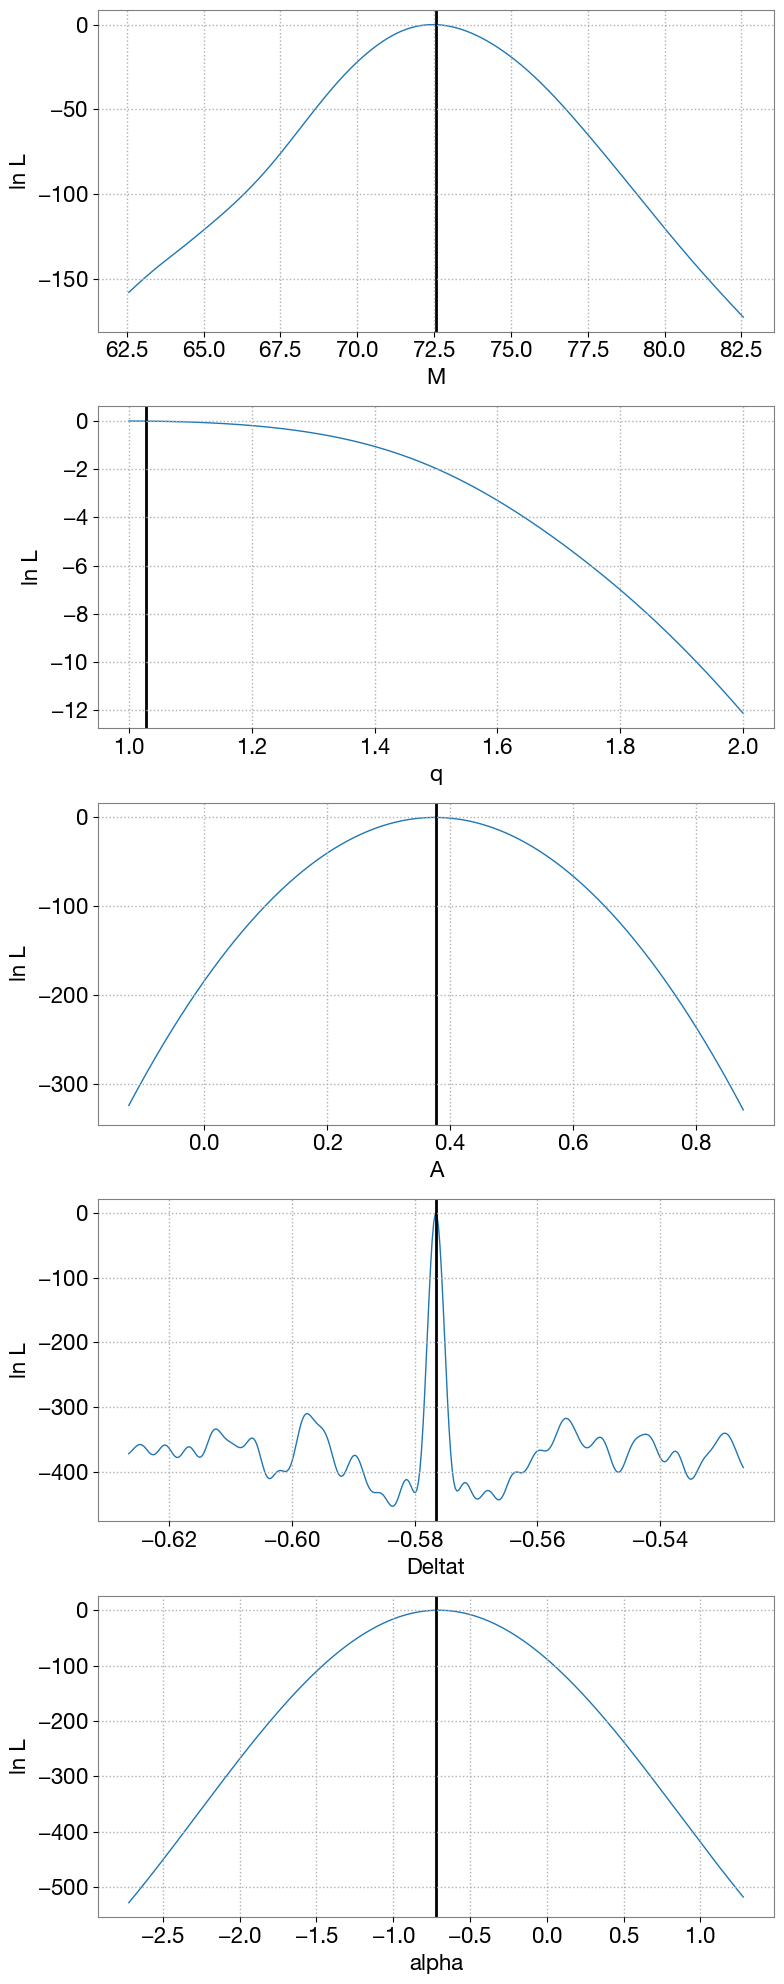

In [160]:
fig, axs = plt.subplots(5,1, figsize=[8,20])
for ip,param in enumerate(list_params):
    axs[ip].plot(param_vals[param], lnlike_vals[param] - lnL_max)
    axs[ip].axvline(x_max[ip], c='k', lw=2.)
    axs[ip].set_xlabel(r'' + param)
    axs[ip].set_ylabel(r'ln L')
fig.tight_layout()

## Building a Fisher matrix

Recall that we the inner product intervening in the matched filter statistic and the likelihood is
$$ ( a | b ) = 4 \mathrm{Re} \int_{0}^{+\infty} df \; \frac{\tilde{a}^{*}(f)\tilde{b}(f)}{S_n(f)}$$

The likelihood in zero noise with a true signal $h_0$ is $\ln \mathcal{L} = - (h_0 -h |h_0 -h)/2$, becomes at leading order in parameter deviations $\Delta \theta^i$:
$$ \ln \mathcal{L}(\theta) = -\frac{1}{2} \Delta \theta^{j} \Delta \theta^{k} (\partial_{j} h | \partial_{k} h) + \mathcal{O} (\Delta \theta^{3})$$
This corresponds to a Gaussian approximation of the likelihood near its peak, and we can estimate the covariance as the inverse $\Gamma^{-1}$ of the Fisher matrix:
$$ \Gamma_{jk} = (\partial_{j} h | \partial_{k} h)$$
Waveform derivatives can be computed numerically by finite differences: (althoug some derivatives are analytical here, like $A$ and $\alpha$)
$$ \partial_{\theta^i} h = \frac{h(\theta^i + \varepsilon^i) - h(\theta^i - \varepsilon^i)}{2\varepsilon} $$
(abuse of notation, the other parameters are kept fixed). The steps $\varepsilon^i$ must be chosen within a certain range to achieve numerical stability of the derivative for each parameter.

In [105]:
list_params = ['M', 'q', 'A', 'Deltat', 'alpha']

def signal_dh(param, step, freq, M, q, A, Deltat, alpha):
    params = np.array([M, q, A, Deltat, alpha])
    params_plus = params.copy()
    params_minus = params.copy()
    i_param = list_params.index(param)
    params_plus[i_param] += step
    params_minus[i_param] -= step
    f, h2m2_plus = signal_h(freq, *params_plus)
    f, h2m2_minus = signal_h(freq, *params_minus)
    return f, (h2m2_plus - h2m2_minus) / (2*step)

def fisher(freq, M, q, A, Deltat, alpha, steps, list_params=list_params, return_cov=True):
    n_params = len(list_params)
    dh = {}
    for param in list_params:
        _, dh[param] = signal_dh(param, steps[param], freq, M, q, A, Deltat, alpha)
    fisher_matrix = np.empty((n_params, n_params), dtype=float)
    for i in range(n_params):
        for j in range(n_params):
            integrand = np.real(dh[list_params[i]] * np.conj(dh[list_params[j]])) * invpsd_vals
            fisher_matrix[i,j] = 4*df* np.sum((integrand[1:] + integrand[:-1]) / 2)
    fisher_cov = None
    if return_cov:
        fisher_cov = np.linalg.inv(fisher_matrix)
    return fisher_matrix, fisher_cov

## Checking the steps for numerical derivatives

The steps $\varepsilon^i$ for the numerical derivatives must be chosen within a certain range to achieve numerical stability of the derivative for each parameter.
- for each parameter, compute just the diagonal element $\Gamma_{jj} = (\partial_j h | \partial_j h)$ for the parameter $\theta^j$, for a wide range (in log) of possible values for the small step
- look for an extended plateau where it looks like the result are stable
- choose an $\varepsilon^j$ within that plateau

In [167]:
steps_base = {'M':1e-5, 'q':1e-5, 'A':1e-5, 'Deltat':1e-7, 'alpha':1e-5}
fisher_vals = {}

Text(0, 0.5, 'Fisher element')

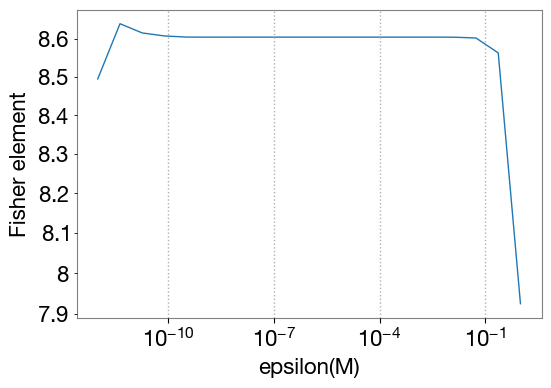

In [168]:
param = 'M'
npt = 20
steps_test = np.geomspace(1e-12, 1., npt)
fisher_vals[param] = np.zeros(npt, dtype=float)
for i in range(npt):
    fisher_step, _ = fisher(freq, M_max, q_max, A_max, Deltat_max, alpha_max, {param:steps_test[i]}, list_params=[param], return_cov=False)
    fisher_vals[param][i] = fisher_step[0,0]

fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.loglog(steps_test, fisher_vals[param])
ax.set_xlabel(r'epsilon(' + param + ')')
ax.set_ylabel(r'Fisher element')

Text(0, 0.5, 'Fisher element')

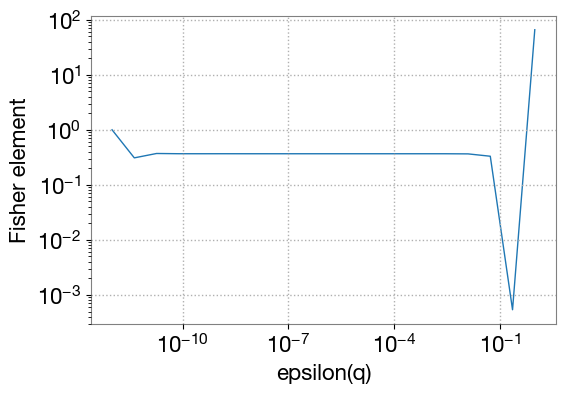

In [169]:
param = 'q'
npt = 20
steps_test = np.geomspace(1e-12, 1., npt)
fisher_vals[param] = np.zeros(npt, dtype=float)
for i in range(npt):
    fisher_step, _ = fisher(freq, M_max, q_max, A_max, Deltat_max, alpha_max, {param:steps_test[i]}, list_params=[param], return_cov=False)
    fisher_vals[param][i] = fisher_step[0,0]

fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.loglog(steps_test, fisher_vals[param])
ax.set_xlabel(r'epsilon(' + param + ')')
ax.set_ylabel(r'Fisher element')

Text(0, 0.5, 'Fisher element')

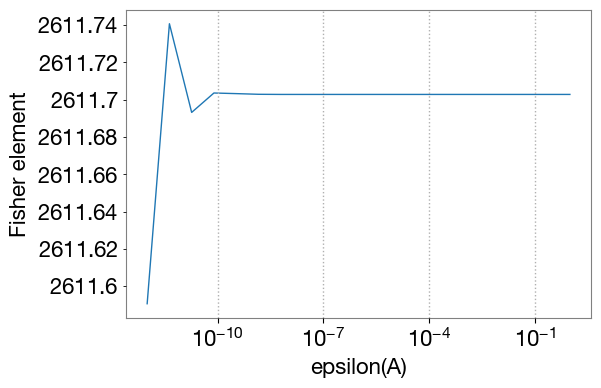

In [170]:
param = 'A'
npt = 20
steps_test = np.geomspace(1e-12, 1., npt)
fisher_vals[param] = np.zeros(npt, dtype=float)
for i in range(npt):
    fisher_step, _ = fisher(freq, M_max, q_max, A_max, Deltat_max, alpha_max, {param:steps_test[i]}, list_params=[param], return_cov=False)
    fisher_vals[param][i] = fisher_step[0,0]

fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.loglog(steps_test, fisher_vals[param])
ax.set_xlabel(r'epsilon(' + param + ')')
ax.set_ylabel(r'Fisher element')

Text(0, 0.5, 'Fisher element')

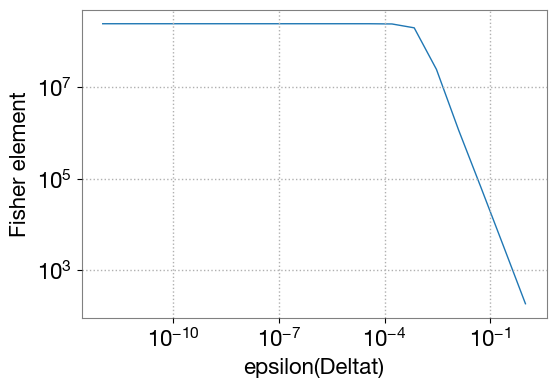

In [171]:
param = 'Deltat'
npt = 20
steps_test = np.geomspace(1e-12, 1., npt)
fisher_vals[param] = np.zeros(npt, dtype=float)
for i in range(npt):
    fisher_step, _ = fisher(freq, M_max, q_max, A_max, Deltat_max, alpha_max, {param:steps_test[i]}, list_params=[param], return_cov=False)
    fisher_vals[param][i] = fisher_step[0,0]

fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.loglog(steps_test, fisher_vals[param])
ax.set_xlabel(r'epsilon(' + param + ')')
ax.set_ylabel(r'Fisher element')

Text(0, 0.5, 'Fisher element')

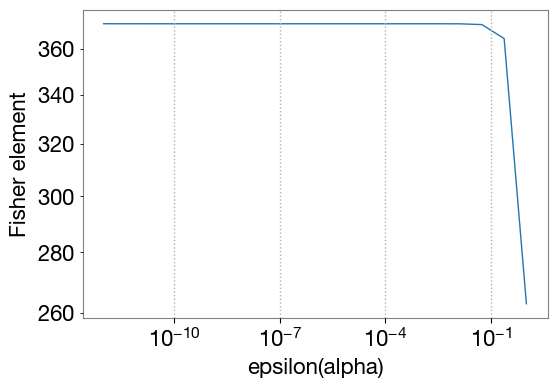

In [172]:
param = 'alpha'
npt = 20
steps_test = np.geomspace(1e-12, 1., npt)
fisher_vals[param] = np.zeros(npt, dtype=float)
for i in range(npt):
    fisher_step, _ = fisher(freq, M_max, q_max, A_max, Deltat_max, alpha_max, {param:steps_test[i]}, list_params=[param], return_cov=False)
    fisher_vals[param][i] = fisher_step[0,0]

fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.loglog(steps_test, fisher_vals[param])
ax.set_xlabel(r'epsilon(' + param + ')')
ax.set_ylabel(r'Fisher element')

## Comparing the Fisher and Bayesian results 

We want now to compare the Fisher result for the covariance to the posterior samples. The Fisher will be computed at the max-likelihood point (we don't have and never will have the true parameters !)
- compute our reference $\Gamma_{jk}$ at $\theta_{\rm max}$ for the max-likelihood
- draw 'samples' from that covariance using `np.random.multivariate_normal`, reject the ones with $q<1$ (a cheap way of enforcing our priors)
- compare to our posterior samples in a corner plot

In [163]:
M_max, q_max, A_max, Deltat_max, alpha_max = x_max
x_max

array([72.56396372,  1.02792874,  0.37700378, -0.57649735,
       -0.72063913])

In [164]:
steps = {'M':1e-5, 'q':1e-5, 'A':1e-5, 'Deltat':1e-7, 'alpha':1e-5}
fisher_test, cov_test = fisher(freq, M_max, q_max, A_max, Deltat_max, alpha_max, steps, list_params=list_params, return_cov=True)

In [165]:
# Marginalized 1-simga errors
np.sqrt(np.diag(cov_test))

array([1.21445788e+00, 4.01959589e+00, 2.57492267e-02,
       4.06700770e-04, 2.86888096e-01])

In [174]:
samples_fishercov = np.random.multivariate_normal(x_max, cov_test, size=100000)
samples_fishercov = samples_fishercov[samples_fishercov[:,1] > 1.]
samples_fishercov.shape

(50160, 5)

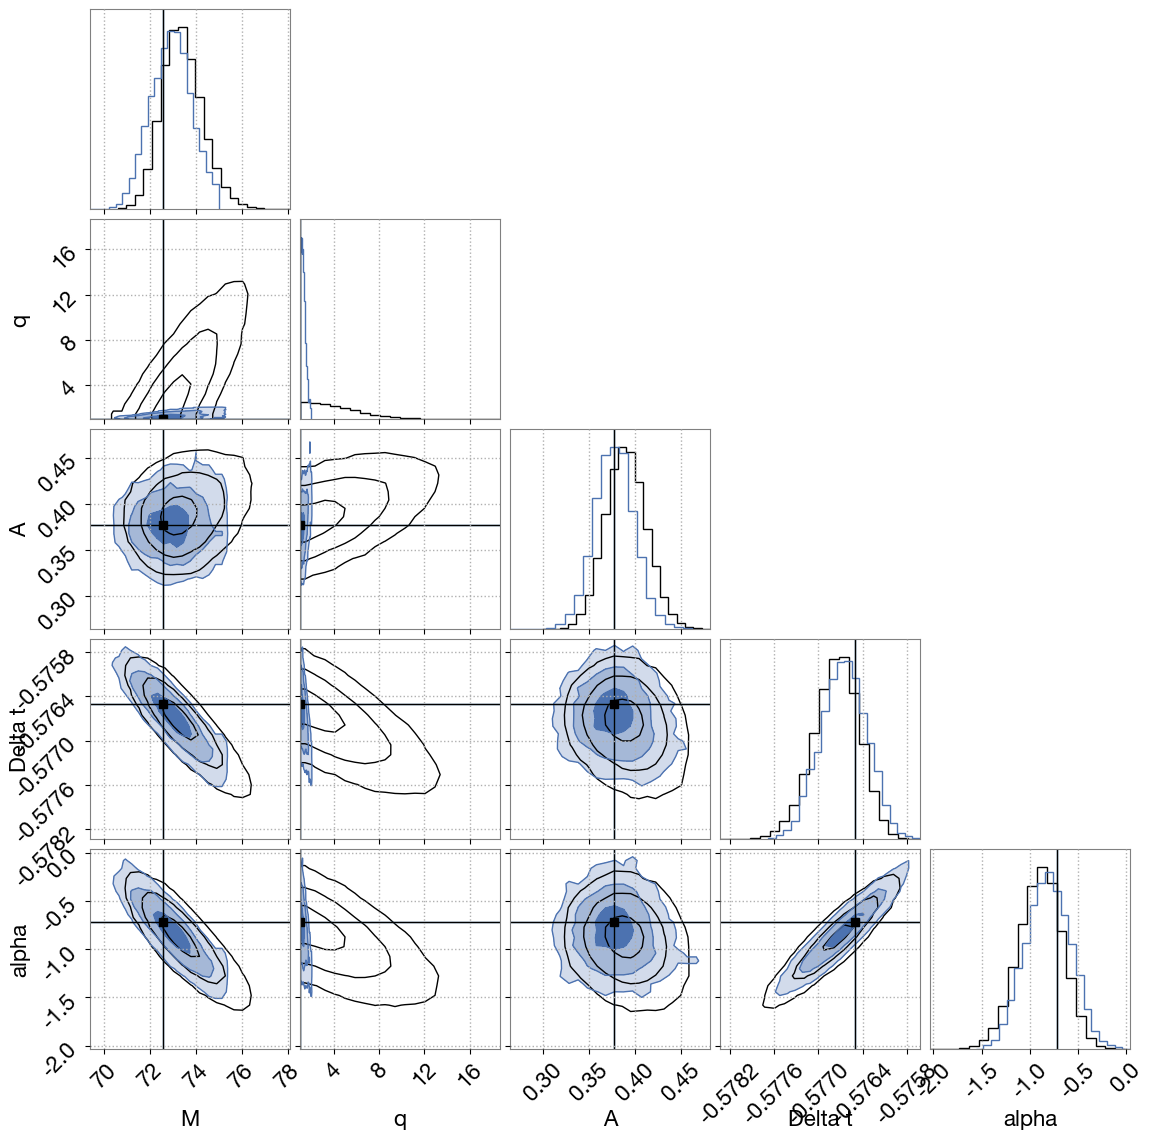

In [176]:
# Plotting syntax for multiple corners:
# fig = corner.corner(samples_1, ...)
# corner.corner(samples_2, fig=fig, ...)

labels = [r'M', r'q', r'A', r'Delta t', r'alpha']
levels = 1.0 - np.exp(-0.5 * np.linspace(1.0, 3.0, num=3) ** 2)

fig = corner.corner(samples_fishercov, plot_density=False, plot_datapoints=False, levels=levels, truths=x_max, smooth=0.5, color='k', fill_contours=False, labels=labels ,hist_kwargs={'density':True});
corner.corner(samples_flat, fig=fig, plot_density=False, plot_datapoints=False, levels=levels, truths=x_max, truth_color='k', smooth=0.5, color='#4C72B0', fill_contours=True, labels=labels, hist_kwargs={'density':True});

# Debug

In [123]:
signal_lnLmax = {}
signal_lnLmax['amp'] = np.load('../../gwda/gwda/test/test_h_lnLmax_amp.npy')
signal_lnLmax['phase'] = np.load('../../gwda/gwda/test/test_h_lnLmax_phase.npy')

In [134]:
M, q, A, Deltat, alpha = np.array([ 7.32045084e+01,  1.32900290e+00,  3.94760472e-01,  4.27858963e-01,
        -5.70273657e-02])
signal_lnLmax_new = signal_h(freq, M, q, A, Deltat, alpha)

In [130]:
m1 = M * q / (1+q)
m2 = M * 1. / (1+q)
dist = 1e3
chi1 = 0.
chi2 = 0.
wfClass = pyIMRPhenomD.IMRPhenomDh22AmpPhase(freq, m1, m2, chi1, chi2, dist)
hlm = wfClass.get_waveform()
h = hlm[(2,2)]
h['phase']

array([148.32365525, 147.49805261, 146.67953592, ...,
         0.        ,   0.        ,   0.        ], shape=(32447,))

In [132]:
h['phase'].shape

(32447,)

In [131]:
freq

array([  10.03125,   10.0625 ,   10.09375, ..., 1023.90625,
       1023.9375 , 1023.96875], shape=(32447,))

In [125]:
signal_lnLmax_new['amp'] / signal_lnLmax['amp']

array([1., 1., 1., ..., 0., 0., 0.], shape=(32447,))

In [135]:
signal_lnLmax_new['phase'] + signal_lnLmax['phase']

array([0.        , 0.        , 0.        , ..., 1.55104607,
       1.5512192 , 1.55139234], shape=(32447,))